# Проект. Исследование стартапов

### Описание данных

#### Файл cb_investments содержит информацию о компаниях и состоявшемся финансировании:
- name — название компании;
- homepage_url — ссылка на сайт компании;
- category_list — категории, в которых работает компания. Указываются через |;
- market — основной рынок или отрасль компании;
- funding_total_usd — общий объём привлечённых инвестиций в долларах США;
- status — текущий статус компании, например, operating, closed и так далее;
- country_code — код страны, например USA;
- state_code — код штата или региона, например CA;
- region — регион, например SF Bay Area;
- city — город, в котором расположена компания;
- funding_rounds — общее число раундов финансирования;
- participants — число участников в раундах финансирования;
- founded_at — дата основания компании;
- founded_month — месяц основания в формате YYYY-MM;
- founded_quarter — квартал основания в формате YYYY-QN;
- founded_year — год основания;
- first_funding_at — дата первого финансирования;
- mid_funding_at — дата среднего по времени раунда финансирования;
- last_funding_at — дата последнего финансирования;
- seed — сумма инвестиций на посевной стадии;
- venture — сумма венчурных инвестиций;
- equity_crowdfunding — сумма, привлечённая через долевой краудфандинг;
- undisclosed — сумма финансирования нераскрытого типа;
- convertible_note — сумма инвестиций через конвертируемые займы;
- debt_financing — сумма долгового финансирования;
- angel — сумма инвестиций от бизнес-ангелов;
- grant — сумма полученных грантов;
- private_equity — сумма инвестиций в виде прямых (частных) вложений;
- post_ipo_equity — сумма финансирования после IPO;
- post_ipo_debt — сумма долгового финансирования после IPO;
- secondary_market — сумма сделок на вторичном рынке;
- product_crowdfunding — сумма, привлечённая через продуктовый краудфандинг;
- round_A — round_H — сумма инвестиций в соответствующем раунде.

#### Файл cb_returns cодержит информацию об объёмах возвратов по годам и типам финансирования в миллионах долларов:
- year — год возврата средств;
- seed — сумма возвратов от посевных инвестиций;
- venture — сумма возвратов от венчурных инвестиций;
- equity_crowdfunding — сумма, возвращённая по долевому краудфандингу;
- undisclosed — сумма возвратов нераскрытого типа;
- convertible_note — сумма возвратов через конвертируемые займы;
- debt_financing — сумма возвратов от долгового финансирования;
- angel — сумма возвратов бизнес-ангелам;
- grant — сумма возвратов по грантам;
- private_equity — сумма возвратов прямых (частных) вложений;
- post_ipo_equity — сумма возвратов от IPO;
- post_ipo_debt — сумма возвратов от долгового IPO;
- secondary_market — сумма возвратов от сделок на вторичном рынке;
- product_crowdfunding — сумма возвратов по продуктовому краудфандингу.

## 1. Знакомство с данными: загрузка и предобработка

In [4]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from datetime import datetime, timedelta

In [5]:
# Выгружаем данные в переменные cb_investments и cb_returns
cb_investments = pd.read_csv("ХХХ", sep=';', low_memory=False)
cb_returns = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv")

### 1.1. Вывод общей информации

#### 1.1.1. Анализ данных cb_investments

In [6]:
print("Первые строки cb_investments:")
display(cb_investments.head())

Первые строки cb_investments:


,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
print("Информация о данных cb_investments:\n")
cb_investments.info()

Информация о данных cb_investments:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-n

In [8]:
print(f"Общее количество записей: {cb_investments.shape[0]}")
print(f"Общее количество столбцов: {cb_investments.shape[1]}")
print(f"Названия столбцов: {list(cb_investments.columns)}\n")
print(f"Количество пропусков: \n{cb_investments.isna().sum()}\n")
print(f"Доля пропусков: \n{round(cb_investments.isna().sum()/cb_investments.shape[0]*100,2)}")

Общее количество записей: 54294
Общее количество столбцов: 40
Названия столбцов: ['name', 'homepage_url', 'category_list', ' market ', ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']

Количество пропусков: 
name                     4857
homepage_url             8305
category_list            8817
 market                  8817
 funding_total_usd       4856
status                   6170
country_code            10129
state_code              24133
region                  10129
city                    10972
fund

##### Выводы по данным cb_investments:

1. Объем данных и соответствие описанию

- Объем: Датасет содержит 54 294 записей и 40 столбцов

- Соответствие описанию: Данные в целом соответствуют описанию, однако обнаружены проблемы с названиями некоторых столбцов (лишние пробелы)

2. Пропущенные значения
- Обнаружены пропуски в следующих столбцах:
    - state_code: 24 133 пропусков (44.45%) - очень большое количество пропусков
    - participants: 23 821 пропусков (43.87%) - очень большое количество пропусков
    - mid_funding_at: 24 006 пропусков (44.21%) - очень большое количество пропусков
    - founded_at и founded_year: ~15 740 пропусков (28.99%) - значительное количество
    - category_list и market: 8 817 пропусков (16.24%)
    - homepage_url: 8 305 пропусков (15.30%)
    - country_code и region: ~10 129 пропусков (18.66%)

3. Типы данных
- Числовые поля (float64): funding_rounds, participants, founded_year, seed-venture и другие инвестиционные столбцы - корректны

- Текстовые поля (object): name, homepage_url, category_list, address, status и др. - корректно

- Проблемы:
    - funding_total_usd имеет тип object, но должен быть числовым (float64)
    - Даты (founded_at, first_funding_at и др.) хранятся как object, требуют преобразования в datetime

4. Названия столбцов

- Большинство названий приведены к snake_case

- Обнаружены проблемы: столбцы market и funding_total_usd содержат лишние пробелы в названиях

#### 1.1.2. Анализ данных cb_returns

In [9]:
print("Первые строки cb_returns:")
display(cb_returns.head())

Первые строки cb_returns:


,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [10]:
print("Информация о данных cb_returns:\n")
cb_returns.info()

Информация о данных cb_returns:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 

In [11]:
print(f"Общее количество записей: {cb_returns.shape[0]}")
print(f"Общее количество столбцов: {cb_returns.shape[1]}")
print(f"Названия столбцов: {list(cb_returns.columns)}\n")
print(f"Количество пропусков: \n{cb_returns.isna().sum()}\n")
print(f"Доля пропусков: \n{round(cb_returns.isna().sum()/cb_returns.shape[0]*100,2)}")

Общее количество записей: 15
Общее количество столбцов: 14
Названия столбцов: ['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

Количество пропусков: 
year                    0
seed                    0
venture                 0
equity_crowdfunding     0
undisclosed             0
convertible_note        0
debt_financing          0
angel                   0
grant                   0
private_equity          0
post_ipo_equity         0
post_ipo_debt           0
secondary_market        0
product_crowdfunding    0
dtype: int64

Доля пропусков: 
year                    0.0
seed                    0.0
venture                 0.0
equity_crowdfunding     0.0
undisclosed             0.0
convertible_note        0.0
debt_financing          0.0
angel                   0.0
grant                   0.0
private_equity          0.0
pos

#### Выводы по данным cb_returns

1. Объем данных и соответствие описанию

- Объем: Датасет содержит 15 записей и 14 столбцов

- Соответствие описанию: Данные полностью соответствуют описанию - содержат информацию об объемах возвратов по годам и типам финансирования

2. Пропущенные значения
- Пропущенные значения отсутствуют во всех столбцах

- Все 15 записей содержат полные данные по всем типам финансирования

3. Типы данных
- year (int64) - для года подходит корректно

- Все финансовые показатели (seed, venture, equity_crowdfunding и др.) имеют тип float64 - что соответствует денежным значениям и позволяет работать с данными
- Типы данных оптимально подходят для последующего анализа и визуализации

4. Названия столбцов

- Все названия приведены к snake_case и соответствуют описанию

- Названия столбцов четко отражают содержащуюся в них информацию

### 1.2. Предобработка данных

### Обработка cb_investments

In [12]:
# 1. Нормализация названий столбцов ' market ', ' funding_total_usd '
cb_investments_cleaned = cb_investments.copy()
print(f"Исходные названия: {cb_investments.columns[3:5]}")

# Убираем лишние пробелы в названиях столбцов ' market ', ' funding_total_usd '
cb_investments_cleaned.columns = cb_investments_cleaned.columns.str.strip()
print(f"Исправленные названия: {cb_investments_cleaned.columns[3:5]}")

Исходные названия: Index([' market ', ' funding_total_usd '], dtype='object')
Исправленные названия: Index(['market', 'funding_total_usd'], dtype='object')


In [13]:
# 2. Обработка funding_total_usd 
print(f"Тип данных до: {cb_investments_cleaned['funding_total_usd'].dtype}")
print(f"Пример значений до: {cb_investments_cleaned['funding_total_usd'].head(5).tolist()}")

def clean_funding_value(value):
    if pd.isna(value):
        return np.nan
    
    str_value = str(value).strip()
      # Заменяем проблемные значения на NaN
    if str_value in ['-', '', 'None', 'nan', 'NULL', 'null', 'NaN']:
        return np.nan
    
    # Убираем запятые, пробелы и проверяем, что осталось число
    cleaned = str_value.replace(',', '').replace(' ', '')
    if cleaned == '-' or not cleaned.replace('.', '').replace('-', '').isdigit():
        return np.nan
    
    try:
        return float(cleaned)
    except (ValueError, TypeError):
        return np.nan

cb_investments_cleaned['funding_total_usd'] = cb_investments_cleaned['funding_total_usd'].apply(clean_funding_value)

print(f"\nТип данных после: {cb_investments_cleaned['funding_total_usd'].dtype}")
print(f"Пример значений после: {cb_investments_cleaned['funding_total_usd'].head(5).tolist()}")

Тип данных до: object
Пример значений до: [' 9,00,00,000 ', ' 20,00,000 ', ' 90,00,000 ', ' 77,00,000 ', ' 5,40,000 ']

Тип данных после: float64
Пример значений после: [90000000.0, 2000000.0, 9000000.0, 7700000.0, 540000.0]


In [14]:
 #3. Обработка дат и времени
date_columns = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at', 'founded_month']

for col in date_columns:
    if col in cb_investments_cleaned.columns:
        print(f"\n{col}:")
        print(f"  Тип до: {cb_investments_cleaned[col].dtype}")
        
        if col in ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']:
            cb_investments_cleaned[col] = pd.to_datetime(cb_investments_cleaned[col], errors='coerce')
        elif col == 'founded_month':
            cb_investments_cleaned[col] = pd.to_datetime(cb_investments_cleaned[col], format='%Y-%m', errors='coerce')
        
        print(f"  Тип после: {cb_investments_cleaned[col].dtype}")


founded_at:
  Тип до: object
  Тип после: datetime64[ns]

first_funding_at:
  Тип до: object
  Тип после: datetime64[ns]

mid_funding_at:
  Тип до: object
  Тип после: datetime64[ns]

last_funding_at:
  Тип до: object
  Тип после: datetime64[ns]

founded_month:
  Тип до: object
  Тип после: datetime64[ns]


In [15]:
# 4. Обработка текстовых данных
text_columns = ['name', 'homepage_url', 'category_list', ' market ', 'status', 
                'country_code', 'state_code', 'region', 'city']

text_missing_summary = {}
for col in text_columns:
    if col in cb_investments_cleaned.columns:
        missing_before = cb_investments_cleaned[col].isna().sum()
        # Заполняем пропуски в зависимости от типа столбца
        if col in ['name', 'category_list', ' market ']:
            cb_investments_cleaned[col] = cb_investments_cleaned[col].fillna('Unknown')
        elif col in ['homepage_url']:
            cb_investments_cleaned[col] = cb_investments_cleaned[col].fillna('No URL')
        elif col in ['status']:
            cb_investments_cleaned[col] = cb_investments_cleaned[col].fillna('Unknown Status')
        elif col in ['country_code', 'state_code', 'region', 'city']:
            cb_investments_cleaned[col] = cb_investments_cleaned[col].fillna('Unknown Location')
        
        missing_after = cb_investments_cleaned[col].isna().sum()
        text_missing_summary[col] = {'before': missing_before, 'after': missing_after}
        
print("Результаты обработки текстовых данных:")
for col, counts in text_missing_summary.items():
    print(f"  {col}: {counts['before']} => {counts['after']} пропусков")

Результаты обработки текстовых данных:
  name: 4857 => 0 пропусков
  homepage_url: 8305 => 0 пропусков
  category_list: 8817 => 0 пропусков
  status: 6170 => 0 пропусков
  country_code: 10129 => 0 пропусков
  state_code: 24133 => 0 пропусков
  region: 10129 => 0 пропусков
  city: 10972 => 0 пропусков


In [16]:
# 5. Обработка дубликатов
initial_count = len(cb_investments_cleaned)
print(f"Исходное количество записей: {initial_count}")

# Удаляем полные дубликаты
cb_investments_cleaned = cb_investments_cleaned.drop_duplicates()
after_dedup = len(cb_investments_cleaned)
print(f"После удаления дубликатов: {after_dedup}")
print(f"Удалено дубликатов: {initial_count - after_dedup}")

Исходное количество записей: 54294
После удаления дубликатов: 49439
Удалено дубликатов: 4855


In [17]:
# 6. Удаление неинформативных строк
investment_cols = ['seed', 'venture', 'equity_crowdfunding', 'funding_total_usd']
print(f"Размер до фильтрации: {len(cb_investments_cleaned)}")

# Проверяем, есть ли хоть одно ненулевое значение в инвестиционных столбцах
has_any_funding = (
    (cb_investments_cleaned[investment_cols] > 0).any(axis=1) | 
    (cb_investments_cleaned[investment_cols].notna().any(axis=1))
)

cb_investments_cleaned = cb_investments_cleaned[has_any_funding]
print(f"После удаления строк без финансирования: {len(cb_investments_cleaned)}")

# Удаляем строки где все инвестиционные столбцы = 0 или NaN
all_investment_cols = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
                      'convertible_note', 'debt_financing', 'angel', 'grant', 
                      'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
                      'secondary_market', 'product_crowdfunding', 'funding_total_usd']

has_real_funding = (cb_investments_cleaned[all_investment_cols] > 0).any(axis=1)
cb_investments_cleaned = cb_investments_cleaned[has_real_funding]
print(f"После удаления строк с нулевым финансированием: {len(cb_investments_cleaned)}")

Размер до фильтрации: 49439
После удаления строк без финансирования: 49438
После удаления строк с нулевым финансированием: 40907


In [18]:
# 7. Заполнение пропусков в mid_funding_at
missing_mid_before = cb_investments_cleaned['mid_funding_at'].isna().sum()
print(f"Пропусков в mid_funding_at до обработки: {missing_mid_before}")

# Заполняем mid_funding_at как середину между first_funding_at и last_funding_at
mask = (cb_investments_cleaned['mid_funding_at'].isna() & 
        cb_investments_cleaned['first_funding_at'].notna() & 
        cb_investments_cleaned['last_funding_at'].notna())

fill_count = mask.sum()
print(f"Можно заполнить записей: {fill_count}")

if fill_count > 0:
    # Вычисляем середину интервала
    time_diff = cb_investments_cleaned.loc[mask, 'last_funding_at'] - cb_investments_cleaned.loc[mask, 'first_funding_at']
    cb_investments_cleaned.loc[mask, 'mid_funding_at'] = cb_investments_cleaned.loc[mask, 'first_funding_at'] + time_diff / 2
    print(f"Успешно заполнено: {fill_count} записей")

missing_mid_after = cb_investments_cleaned['mid_funding_at'].isna().sum()
print(f"Пропусков в mid_funding_at после обработки: {missing_mid_after}")

Пропусков в mid_funding_at до обработки: 13676
Можно заполнить записей: 13675
Успешно заполнено: 13675 записей
Пропусков в mid_funding_at после обработки: 1


### Обработка cb_returns

In [19]:
cb_returns_cleaned = cb_returns.copy()

# Установка year в качестве индекса
print(f"\nИндекс до: {cb_returns.index.name}")
cb_returns_cleaned.set_index('year', inplace=True)
print(f"\nИндекс после: {cb_returns_cleaned.index.name}")


Индекс до: None

Индекс после: year


### Проверка cb_investments_cleaned и cb_returns_cleaned

In [20]:
# Оценка cb_investments
initial_investments = 54294  # исходный размер
final_investments = len(cb_investments_cleaned)
discarded_investments = initial_investments - final_investments
discarded_percent = (discarded_investments / initial_investments) * 100

print("cb_investments:")
print(f"  Исходный размер: {initial_investments}")
print(f"  Финальный размер: {final_investments}")
print(f"  Отброшено записей: {discarded_investments} ({discarded_percent:.2f}%)")

# Оценка cb_returns
print(f"\ncb_returns:")
print(f"  Размер: {len(cb_returns_cleaned)} записей, {len(cb_returns_cleaned.columns)} столбцов")
print(f"  Диапазон лет: {cb_returns_cleaned.index.min()} - {cb_returns_cleaned.index.max()}")

cb_investments:
  Исходный размер: 54294
  Финальный размер: 40907
  Отброшено записей: 13387 (24.66%)

cb_returns:
  Размер: 15 записей, 13 столбцов
  Диапазон лет: 2000 - 2014


**Вывод о пригодности данных**

- cb_investments: достаточно полные данные
- cb_returns: данные без пропусков
- Оба датасета готовы для дальнейшего анализа

---

## 2.  Инжиниринг признаков


### 2.1. Группы по срокам финансирования

In [21]:
# Устанавливаем стиль и цветовую палитру
plt.style.use('default')
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1'] 

df = cb_investments_cleaned

# 1. Оставляем только компании с данными о финансировании
df_clean = df[
    df['funding_rounds'].notna() & 
    df['first_funding_at'].notna() & 
    df['last_funding_at'].notna() &
    df['funding_total_usd'].notna() &
    (df['funding_total_usd'] > 0)
].copy()

print(f"Компаний с полными данными о финансировании: {len(df_clean)}")

Компаний с полными данными о финансировании: 40905


In [22]:
# 2. Создание групп по срокам финансирования

# Группа 1: Единичное финансирование
single_funding = df_clean[df_clean['funding_rounds'] == 1].copy()
single_funding['funding_group'] = 'Единичное финансирование'

# Группа 2: Множественное финансирование
multiple_funding = df_clean[df_clean['funding_rounds'] > 1].copy()

# Вычисляем длительность финансирования в днях
multiple_funding['funding_duration_days'] = (
    multiple_funding['last_funding_at'] - multiple_funding['first_funding_at']
).dt.days

# Группа 2a: Срок финансирования до года (≤ 365 дней)
short_term = multiple_funding[multiple_funding['funding_duration_days'] <= 365].copy()
short_term['funding_group'] = 'Срок финансирования до года'

# Группа 2b: Срок финансирования более года (> 365 дней)
long_term = multiple_funding[multiple_funding['funding_duration_days'] > 365].copy()
long_term['funding_group'] = 'Срок финансирования более года'

# Объединяем все группы
groups_df = pd.concat([single_funding, short_term, long_term], ignore_index=True)

# Статистика по группам
print("Статистика по группам финансирования:")
group_stats = groups_df.groupby('funding_group').agg({
    'name': 'count',
    'funding_total_usd': 'sum',
    'funding_rounds': 'mean',
    'funding_duration_days': 'mean'
}).round(2)

group_stats.columns = ['Количество компаний', 'Сумма инвестиций', 'Среднее число раундов', 'Средняя длительность (дни)']
print(group_stats)



Статистика по группам финансирования:
                                Количество компаний  Сумма инвестиций  \
funding_group                                                           
Единичное финансирование                      24113      1.993044e+11   
Срок финансирования более года                12291      4.027090e+11   
Срок финансирования до года                    4501      4.888598e+10   

                                Среднее число раундов  \
funding_group                                           
Единичное финансирование                         1.00   
Срок финансирования более года                   3.31   
Срок финансирования до года                      2.18   

                                Средняя длительность (дни)  
funding_group                                               
Единичное финансирование                               NaN  
Срок финансирования более года                     1155.11  
Срок финансирования до года                         195.94  


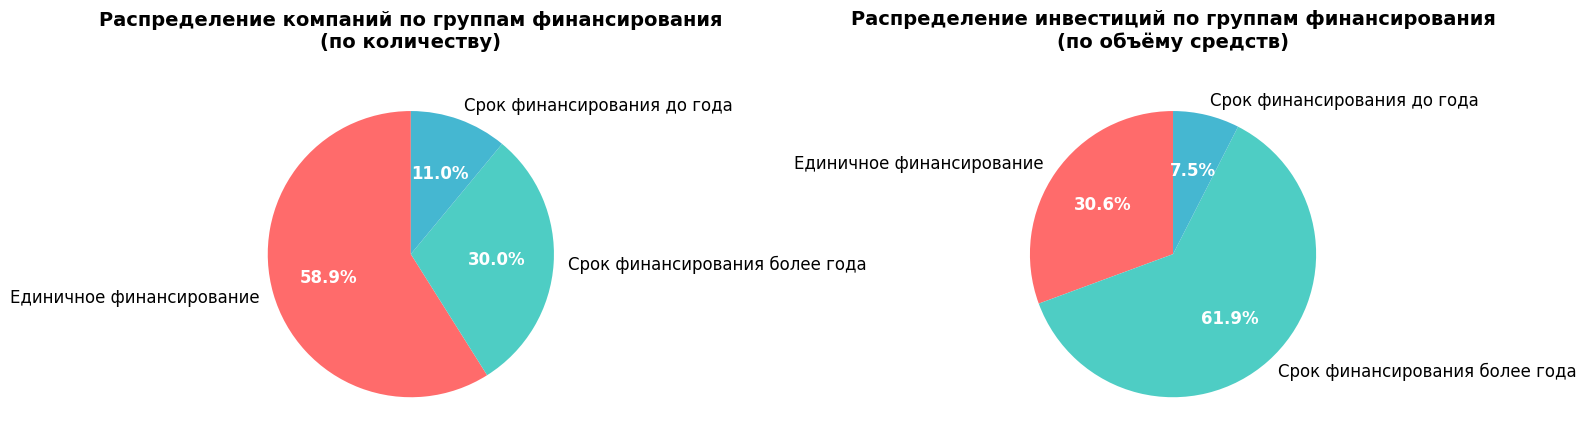

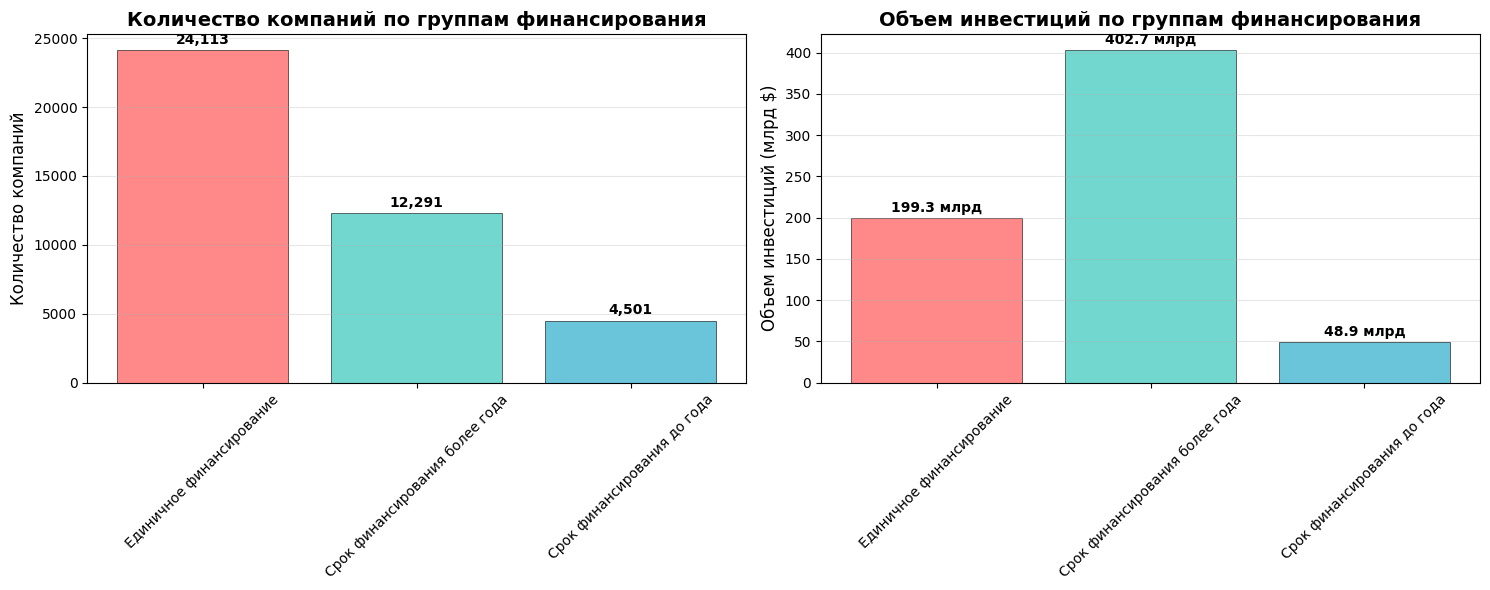

In [23]:
# 3. Визуализация результатов

# Создаем фигуру с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Данные для графиков
labels = groups_df['funding_group'].value_counts().index
company_counts = groups_df['funding_group'].value_counts().values
investment_totals = groups_df.groupby('funding_group')['funding_total_usd'].sum()

# График 1: Распределение по количеству компаний
wedges1, texts1, autotexts1 = ax1.pie(company_counts, labels=labels, autopct='%1.1f%%', 
                                      startangle=90, colors=colors, textprops={'fontsize': 12})
ax1.set_title('Распределение компаний по группам финансирования\n(по количеству)', 
              fontsize=14, fontweight='bold', pad=20)

# График 2: Распределение по объёму инвестиций
wedges2, texts2, autotexts2 = ax2.pie(investment_totals, labels=labels, autopct='%1.1f%%', 
                                      startangle=90, colors=colors, textprops={'fontsize': 12})
ax2.set_title('Распределение инвестиций по группам финансирования\n(по объёму средств)', 
              fontsize=14, fontweight='bold', pad=20)

for autotext in autotexts1 + autotexts2:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

# 4. Столбчатые диаграммы
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Столбчатая диаграмма: количество компаний
bars1 = ax1.bar(labels, company_counts, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
ax1.set_title('Количество компаний по группам финансирования', fontsize=14, fontweight='bold')
ax1.set_ylabel('Количество компаний', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + max(company_counts)*0.01,
             f'{height:,}', ha='center', va='bottom', fontweight='bold')

# Столбчатая диаграмма: объем инвестиций (в миллиардах)
investment_billions = investment_totals / 1e9
bars2 = ax2.bar(labels, investment_billions, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
ax2.set_title('Объем инвестиций по группам финансирования', fontsize=14, fontweight='bold')
ax2.set_ylabel('Объем инвестиций (млрд $)', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + max(investment_billions)*0.01,
             f'{height:.1f} млрд', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()



In [24]:
# 5. Cтатистика

total_companies = len(groups_df)
total_investment = groups_df['funding_total_usd'].sum()

print(f"Общее количество компаний в анализе: {total_companies:,}")
print(f"Общий объем инвестиций: ${total_investment:,.0f}")

print("\nРаспределение по группам:")
for i, group in enumerate(labels):
    companies_pct = (company_counts[i] / total_companies) * 100
    investment_pct = (investment_totals[group] / total_investment) * 100
    
    print(f"\n{group}:")
    print(f"  Количество компаний: {company_counts[i]:,} ({companies_pct:.1f}%)")
    print(f"  Объем инвестиций: ${investment_totals[group]:,.0f} ({investment_pct:.1f}%)")
    print(f"  Средний объем инвестиций на компанию: ${investment_totals[group]/company_counts[i]:,.0f}")


Общее количество компаний в анализе: 40,905
Общий объем инвестиций: $650,899,403,144

Распределение по группам:

Единичное финансирование:
  Количество компаний: 24,113 (58.9%)
  Объем инвестиций: $199,304,424,483 (30.6%)
  Средний объем инвестиций на компанию: $8,265,435

Срок финансирования более года:
  Количество компаний: 12,291 (30.0%)
  Объем инвестиций: $402,708,997,604 (61.9%)
  Средний объем инвестиций на компанию: $32,764,543

Срок финансирования до года:
  Количество компаний: 4,501 (11.0%)
  Объем инвестиций: $48,885,981,057 (7.5%)
  Средний объем инвестиций на компанию: $10,861,138


Анализ показал, что большинство компаний получали разовое (едтничное) финансирование (58.9%), однако объем инвестиций был выше в компании, где срок финансирования был более года (61.9% от общего объема инвестиций) 

### 2.2 Выделение средних и нишевых сегментов рынка

In [25]:
# 1. Анализ распределения сегментов рынка
# Заполняем пропуски в market
df['market'] = df['market'].fillna('Unknown')

# Рассчитываем частоту встречаемости каждого сегмента
market_counts = df['market'].value_counts()
print(f"\nВсего уникальных сегментов рынка: {len(market_counts)}")
print(f"Общее количество компаний: {len(df)}")

# Выводим топ-10 самых популярных сегментов
print("\nТоп-10 самых популярных сегментов:")
print(market_counts.head(10))


Всего уникальных сегментов рынка: 849
Общее количество компаний: 40907

Топ-10 самых популярных сегментов:
 Software                4190
 Biotechnology           3531
Unknown                  2503
 Mobile                  1852
 E-Commerce              1528
 Curated Web             1404
 Enterprise Software     1190
 Health Care             1128
 Clean Technology        1094
 Hardware + Software     1008
Name: market, dtype: int64


In [26]:
# 2. Распределение по категориям 
MASS_MARKET_THRESHOLD = 120
MID_MARKET_THRESHOLD = 35

# Создаем DataFrame с классификацией сегментов
market_classification = pd.DataFrame({
    'segment': market_counts.index,
    'company_count': market_counts.values
})

# Классифицируем сегменты
def classify_segment(count):
    if count > MASS_MARKET_THRESHOLD:
        return 'mass'
    elif count >= MID_MARKET_THRESHOLD:
        return 'mid'
    else:
        return 'less'

market_classification['category'] = market_classification['company_count'].apply(classify_segment)

# Статистика по категориям
category_stats = market_classification.groupby('category').agg({
    'segment': 'count',
    'company_count': 'sum'
}).rename(columns={'segment': 'segment_count', 'company_count': 'total_companies'})

print("\nРаспределение по категориям:")
print(category_stats)


Распределение по категориям:
          segment_count  total_companies
category                                
less                714             2494
mass                 54            33344
mid                  81             5069


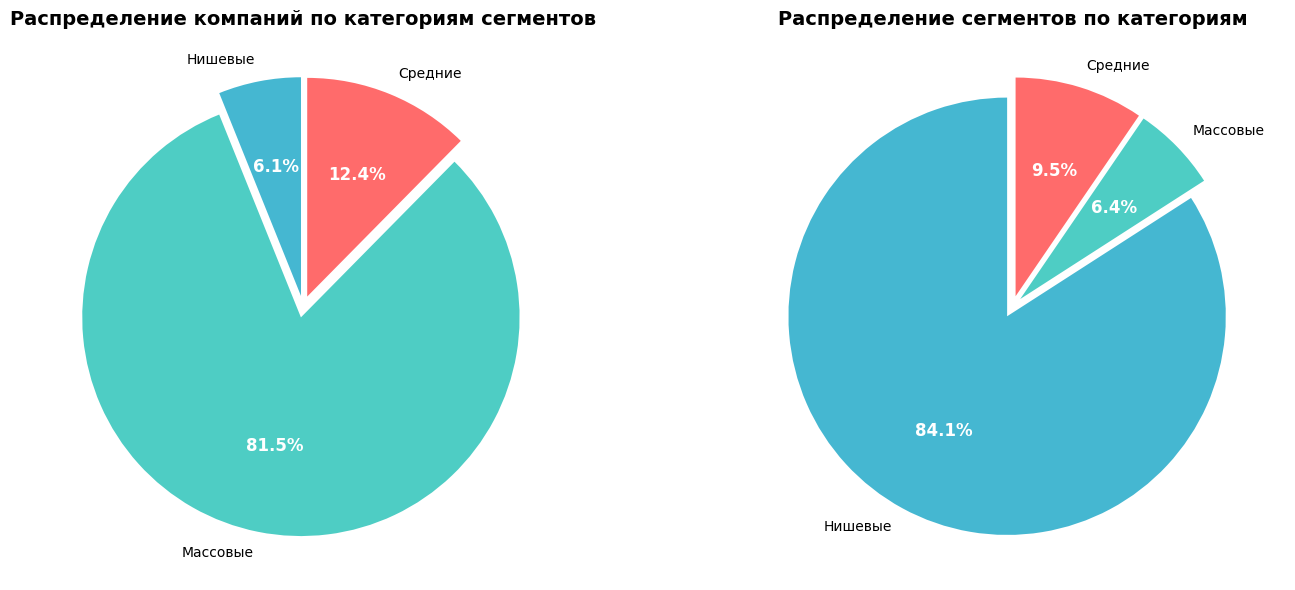


Детальная статистика по категориям:

MASS СЕГМЕНТЫ:
  Количество сегментов: 54
  Общее количество компаний: 33,344
  Среднее количество компаний на сегмент: 617.5
  Медианное количество компаний: 257.5

MID СЕГМЕНТЫ:
  Количество сегментов: 81
  Общее количество компаний: 5,069
  Среднее количество компаний на сегмент: 62.6
  Медианное количество компаний: 57.0

LESS СЕГМЕНТЫ:
  Количество сегментов: 714
  Общее количество компаний: 2,494
  Среднее количество компаний на сегмент: 3.5
  Медианное количество компаний: 2.0


In [27]:
# 3. Круговая диаграмма распределения компаний по категориям
plt.figure(figsize=(15, 6))

category_labels = ['Нишевые', 'Массовые', 'Средние']
colors_pie = ['#45B7D1', '#4ECDC4', '#FF6B6B']  # mass, mid, less

# Круговая диаграмма: распределение компаний по категориям
plt.subplot(1, 2, 1)
category_totals = category_stats['total_companies']
wedges, texts, autotexts = plt.pie(category_totals, labels=category_labels, autopct='%1.1f%%',
                                   colors=colors_pie, startangle=90, explode=(0.05, 0.05, 0.05))

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

plt.title('Распределение компаний по категориям сегментов', fontsize=14, fontweight='bold')

# Круговая диаграмма: распределение сегментов по категориям
plt.subplot(1, 2, 2)
segment_counts = category_stats['segment_count']
wedges2, texts2, autotexts2 = plt.pie(segment_counts, labels=category_labels, autopct='%1.1f%%',
                                      colors=colors_pie, startangle=90, explode=(0.05, 0.05, 0.05))

for autotext in autotexts2:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

plt.title('Распределение сегментов по категориям', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Статистика по категориям
print("\nДетальная статистика по категориям:")
for category in ['mass', 'mid', 'less']:
    category_data = market_classification[market_classification['category'] == category]
    print(f"\n{category.upper()} СЕГМЕНТЫ:")
    print(f"  Количество сегментов: {len(category_data)}")
    print(f"  Общее количество компаний: {category_data['company_count'].sum():,}")
    print(f"  Среднее количество компаний на сегмент: {category_data['company_count'].mean():.1f}")
    print(f"  Медианное количество компаний: {category_data['company_count'].median():.1f}")

In [28]:
# 4. Замена значений в столбце market
replacement_dict = {}
for _, row in market_classification.iterrows():
    if row['category'] == 'mass':
        replacement_dict[row['segment']] = row['segment']  
    elif row['category'] == 'mid':
        replacement_dict[row['segment']] = 'niche'  
    else:  
        replacement_dict[row['segment']] = 'niche'  

df['market_original'] = df['market']  # Сохраняем оригинальные значения
df['market'] = df['market'].map(replacement_dict)

print("Замена завершена:")
print(f"  - Сохранено массовых сегментов: {len(market_classification[market_classification['category'] == 'mass'])}")
print(f"  - Замена на в средней и низшей кактегории 'niche': {len(market_classification[market_classification['category'] == 'mid']) + len(market_classification[market_classification['category'] == 'less'])} сегментов")


Замена завершена:
  - Сохранено массовых сегментов: 54
  - Замена на в средней и низшей кактегории 'niche': 795 сегментов


На массовую категорию (Сегменты, к которым относится более 120 компаний) относится большее количество компаний из выборки (33 344), однако и самое низкое количество сегментов (54)

## 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Всего уникальных сегментов: 55
Топ-10 сегментов по количеству компаний:
niche                    7563
 Software                4190
 Biotechnology           3531
Unknown                  2503
 Mobile                  1852
 E-Commerce              1528
 Curated Web             1404
 Enterprise Software     1190
 Health Care             1128
 Clean Technology        1094
Name: market, dtype: int64

Категоризация сегментов:
Массовые сегменты (mass): 10
Средние сегменты (mid): 20
Нишевые сегменты (less): 25

Распределение компаний по категориям:
mass    25983
mid     10775
less     4149
Name: category, dtype: int64

Статистика по сегментам:
            count          mean           std   min       25%        50%  \
category                                                                   
less       4149.0  1.418297e+07  1.048848e+08   1.0  209800.0  1230000.0   
mass      25983.0  1.678446e+07  2.007382e+08  14.0  355001.5  2000000.0   
mid       10775.0  1.447590e+07  8.130848e+07  30.0

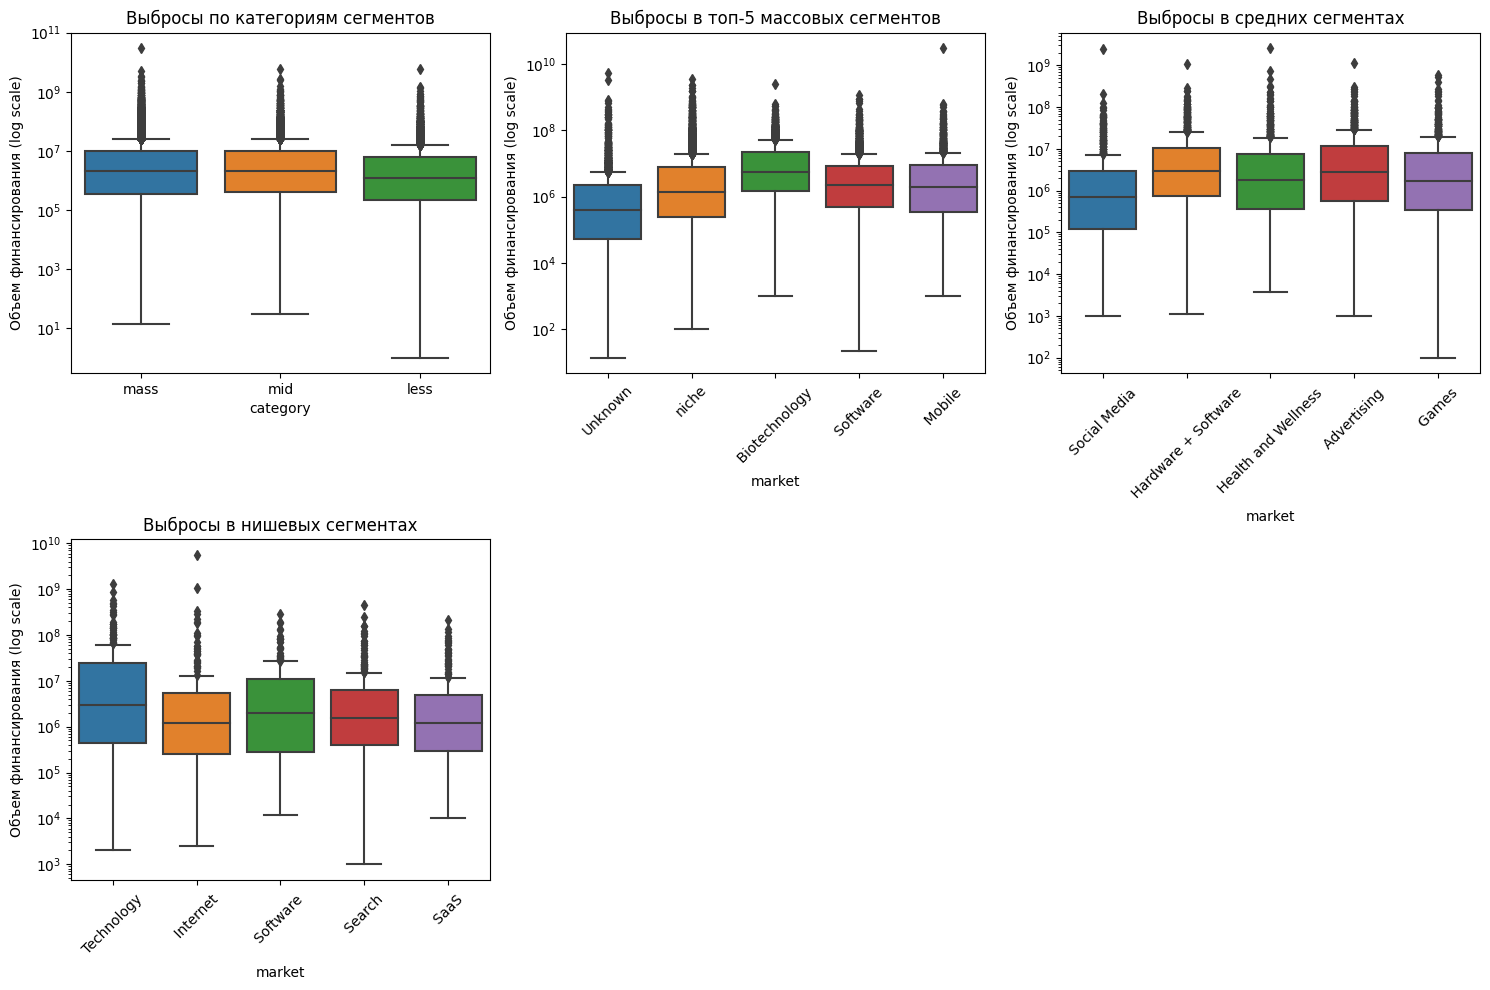


Детальный анализ выбросов по категориям (IQR метод):

MASS категория:
  Всего компаний: 25983
  Всего выбросов: 3450 (13.28%)
  Верхние выбросы: 3450 (13.28%)
  Границы выбросов: -14112496.25 - 24467497.75 USD
  Максимальное финансирование: 30079503000.00 USD
  Медианное финансирование: 2000000.00 USD

MID категория:
  Всего компаний: 10775
  Всего выбросов: 1347 (12.50%)
  Верхние выбросы: 1347 (12.50%)
  Границы выбросов: -14000000.00 - 24400000.00 USD
  Максимальное финансирование: 5800000000.00 USD
  Медианное финансирование: 2125000.00 USD

LESS категория:
  Всего компаний: 4149
  Всего выбросов: 593 (14.29%)
  Верхние выбросы: 593 (14.29%)
  Границы выбросов: -8850500.00 - 15310300.00 USD
  Максимальное финансирование: 5700000000.00 USD
  Медианное финансирование: 1230000.00 USD

Сводная таблица анализа выбросов:
  category  total_companies  outliers_count  upper_outliers_count  \
0     mass            25983            3450                  3450   
1      mid            10775   

In [37]:
plt.style.use('default')
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1'] 

print(f"Всего уникальных сегментов: {df['market'].nunique()}")
print(f"Топ-10 сегментов по количеству компаний:")
print(df['market'].value_counts().head(10))

# Создаем категории на основе частотности сегментов
market_counts = df['market'].value_counts()

mass_markets = market_counts.head(10).index.tolist()
mid_markets = market_counts.iloc[10:30].index.tolist()
less_markets = market_counts.iloc[30:].index.tolist()

print(f"\nКатегоризация сегментов:")
print(f"Массовые сегменты (mass): {len(mass_markets)}")
print(f"Средние сегменты (mid): {len(mid_markets)}")
print(f"Нишевые сегменты (less): {len(less_markets)}")

# Добавляем категоризацию в DataFrame
def categorize_market(market):
    if market in mass_markets:
        return 'mass'
    elif market in mid_markets:
        return 'mid'
    else:
        return 'less'

df['category'] = df['market'].apply(categorize_market)

print(f"\nРаспределение компаний по категориям:")
print(df['category'].value_counts())

# Статистика по сегментам
segment_stats = df.groupby('category')['funding_total_usd'].describe()
print("\nСтатистика по сегментам:")
print(segment_stats)

# Визуализация выбросов с помощью boxplot
plt.figure(figsize=(15, 10))

# 1. Основной boxplot по категориям
plt.subplot(2, 3, 1)
sns.boxplot(data=df, x='category', y='funding_total_usd', order=['mass', 'mid', 'less'])
plt.title('Выбросы по категориям сегментов')
plt.yscale('log')
plt.ylabel('Объем финансирования (log scale)')

# 2. Boxplot для топ-5 массовых сегментов
mass_top5 = df[df['market'].isin(mass_markets[:5])]
plt.subplot(2, 3, 2)
sns.boxplot(data=mass_top5, x='market', y='funding_total_usd')
plt.title('Выбросы в топ-5 массовых сегментов')
plt.yscale('log')
plt.xticks(rotation=45)
plt.ylabel('Объем финансирования (log scale)')

# 3. Boxplot для средних сегментов 
mid_sample = df[df['market'].isin(mid_markets[:5])]
plt.subplot(2, 3, 3)
sns.boxplot(data=mid_sample, x='market', y='funding_total_usd')
plt.title('Выбросы в средних сегментах')
plt.yscale('log')
plt.xticks(rotation=45)
plt.ylabel('Объем финансирования (log scale)')

# 4. Boxplot для нишевых сегментов
less_sample = df[df['market'].isin(less_markets[:5])]
plt.subplot(2, 3, 4)
sns.boxplot(data=less_sample, x='market', y='funding_total_usd')
plt.title('Выбросы в нишевых сегментах')
plt.yscale('log')
plt.xticks(rotation=45)
plt.ylabel('Объем финансирования (log scale)')

plt.tight_layout()
plt.show()

# Анализ выбросов с помощью IQR метода
def detect_outliers_iqr(data_series):
    Q1 = data_series.quantile(0.25)
    Q3 = data_series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_mask = (data_series < lower_bound) | (data_series > upper_bound)
    return outliers_mask, lower_bound, upper_bound

# Анализ выбросов по каждой категории
print("\nДетальный анализ выбросов по категориям (IQR метод):")

outliers_summary = []

for category in ['mass', 'mid', 'less']:
    category_data = df[df['category'] == category]
    funding_data = category_data['funding_total_usd']
    
    outliers_mask, lower_bound, upper_bound = detect_outliers_iqr(funding_data)
    outliers_count = outliers_mask.sum()
    total_count = len(category_data)
    
    # Анализ только верхних выбросов (слишком большое финансирование)
    upper_outliers_mask = funding_data > upper_bound
    upper_outliers_count = upper_outliers_mask.sum()
    
    outliers_summary.append({
        'category': category,
        'total_companies': total_count,
        'outliers_count': outliers_count,
        'upper_outliers_count': upper_outliers_count,
        'outliers_percentage': (outliers_count / total_count) * 100,
        'upper_outliers_percentage': (upper_outliers_count / total_count) * 100,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'max_funding': funding_data.max(),
        'mean_funding': funding_data.mean(),
        'median_funding': funding_data.median()
    })
    
    print(f"\n{category.upper()} категория:")
    print(f"  Всего компаний: {total_count}")
    print(f"  Всего выбросов: {outliers_count} ({outliers_count/total_count*100:.2f}%)")
    print(f"  Верхние выбросы: {upper_outliers_count} ({upper_outliers_count/total_count*100:.2f}%)")
    print(f"  Границы выбросов: {lower_bound:.2f} - {upper_bound:.2f} USD")
    print(f"  Максимальное финансирование: {funding_data.max():.2f} USD")
    print(f"  Медианное финансирование: {funding_data.median():.2f} USD")

outliers_df = pd.DataFrame(outliers_summary)
print("\nСводная таблица анализа выбросов:")
print(outliers_df.round(2))

df['is_outlier'] = False

for category in ['mass', 'mid', 'less']:
    category_data = df[df['category'] == category]
    funding_data = category_data['funding_total_usd']
    
    _, _, upper_bound = detect_outliers_iqr(funding_data)
    upper_outliers_mask = funding_data > upper_bound
    
    df.loc[(df['category'] == category) & upper_outliers_mask, 'is_outlier'] = True

print(f"\nИтоги пометки выбросов:")
print(f"Всего записей в df: {len(df)}")
print(f"Выбросов помечено: {df['is_outlier'].sum()}")
print(f"Доля выбросов в данных: {df['is_outlier'].sum()/len(df)*100:.2f}%")

# Анализ характеристик выбросов
outliers_data = df[df['is_outlier'] == True]
normal_data = df[df['is_outlier'] == False]

print(f"\nХарактеристики выбросов:")
print(f"Средний объем финансирования выбросов: {outliers_data['funding_total_usd'].mean():.2f} USD")
print(f"Медианный объем финансирования выбросов: {outliers_data['funding_total_usd'].median():.2f} USD")
print(f"Средний объем финансирования нормальных значений: {normal_data['funding_total_usd'].mean():.2f} USD")
print(f"Максимальный объем финансирования среди выбросов: {outliers_data['funding_total_usd'].max():.2f} USD")

# Распределение выбросов по категориям
print(f"\nРаспределение выбросов по категориям:")
outliers_by_category = outliers_data['category'].value_counts()
print(outliers_by_category)


### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

После исключения выбросов: 35517 записей (было 40907)
Исключено выбросов: 5390 записей


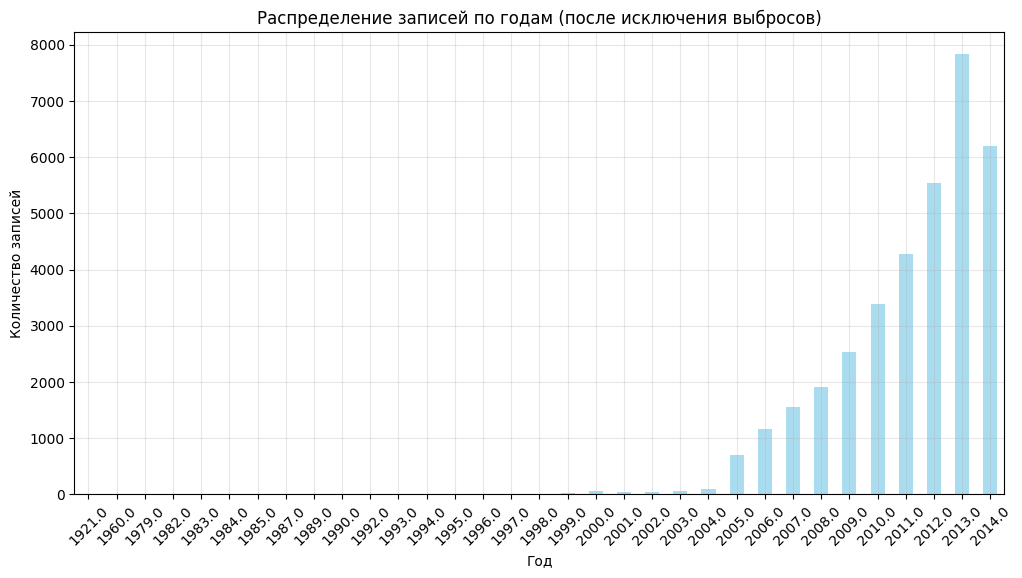

Количество раундов финансирования по годам:
mid_funding_year
1921.0       1
1960.0       2
1979.0       1
1982.0       3
1983.0       1
1984.0       2
1985.0       3
1987.0       2
1989.0       1
1990.0       1
1992.0       4
1993.0       1
1994.0       4
1995.0       3
1996.0       4
1997.0       4
1998.0      10
1999.0      32
2000.0      70
2001.0      41
2002.0      51
2003.0      64
2004.0     103
2005.0     701
2006.0    1162
2007.0    1560
2008.0    1913
2009.0    2542
2010.0    3394
2011.0    4277
2012.0    5537
2013.0    7826
2014.0    6196
dtype: int64

Годы с 50+ раундами финансирования: [2000.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]
Количество подходящих лет: 14


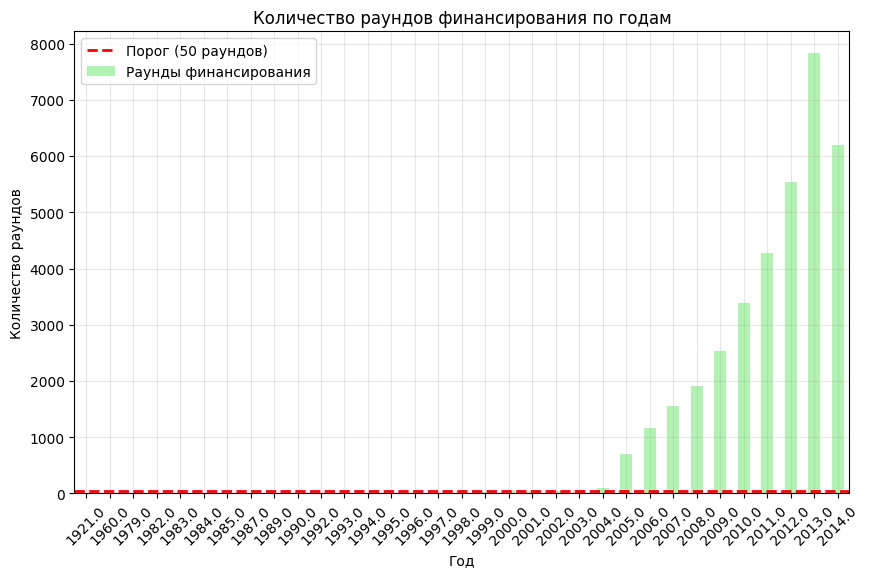

Статистика финансирования по категориям в финальном датасете:
            count        mean         std   min       25%        50%  \
category                                                               
less       3552.0  2298727.34  3280607.64   1.0  155000.0   813635.0   
mass      22439.0  3848557.13  5399336.44  14.0  250000.0  1338000.0   
mid        9405.0  4075273.13  5493795.80  30.0  300000.0  1500000.0   

                75%         max  
category                         
less      3000000.0  15300000.0  
mass      5025000.0  24425000.0  
mid       5515489.0  24374444.0  

Статистика по количеству раундов финансирования:
count    35396.000000
mean         1.598966
std          1.049372
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         16.000000
Name: funding_rounds, dtype: float64


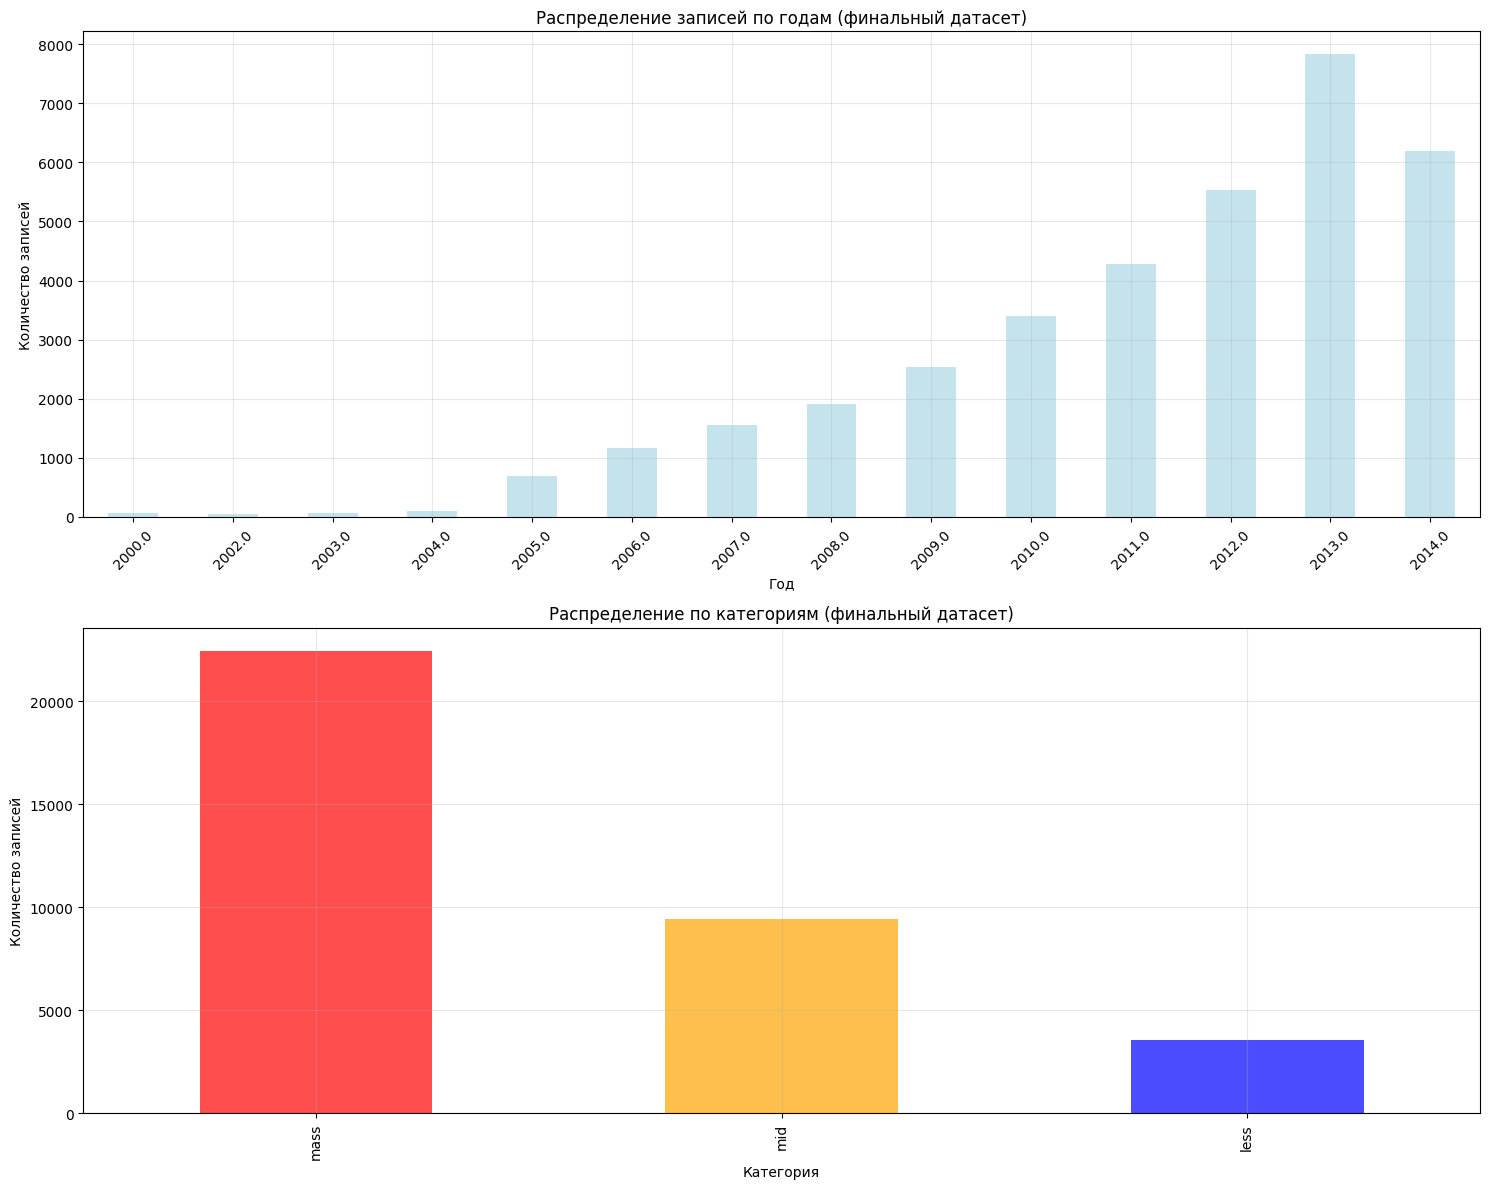

Начальный год анализа: 2000.0
Конечный год анализа: 2014.0
Период анализа: 14.0 лет

Динамика показателей по годам:
                 funding_total_usd                   funding_rounds
                               sum        mean count           mean
mid_funding_year                                                   
2000.0                5.067426e+08  7239179.90    70           1.81
2002.0                3.853989e+08  7556841.86    51           1.94
2003.0                3.715742e+08  5805846.67    64           1.88
2004.0                8.139767e+08  7902686.86   103           1.78
2005.0                4.616183e+09  6585140.02   701           1.35
2006.0                8.010962e+09  6894115.64  1162           1.55
2007.0                9.875585e+09  6330503.01  1560           1.74
2008.0                1.114367e+10  5825231.26  1913           1.79
2009.0                1.184098e+10  4658135.50  2542           1.68
2010.0                1.452151e+10  4278582.39  3394           1.71


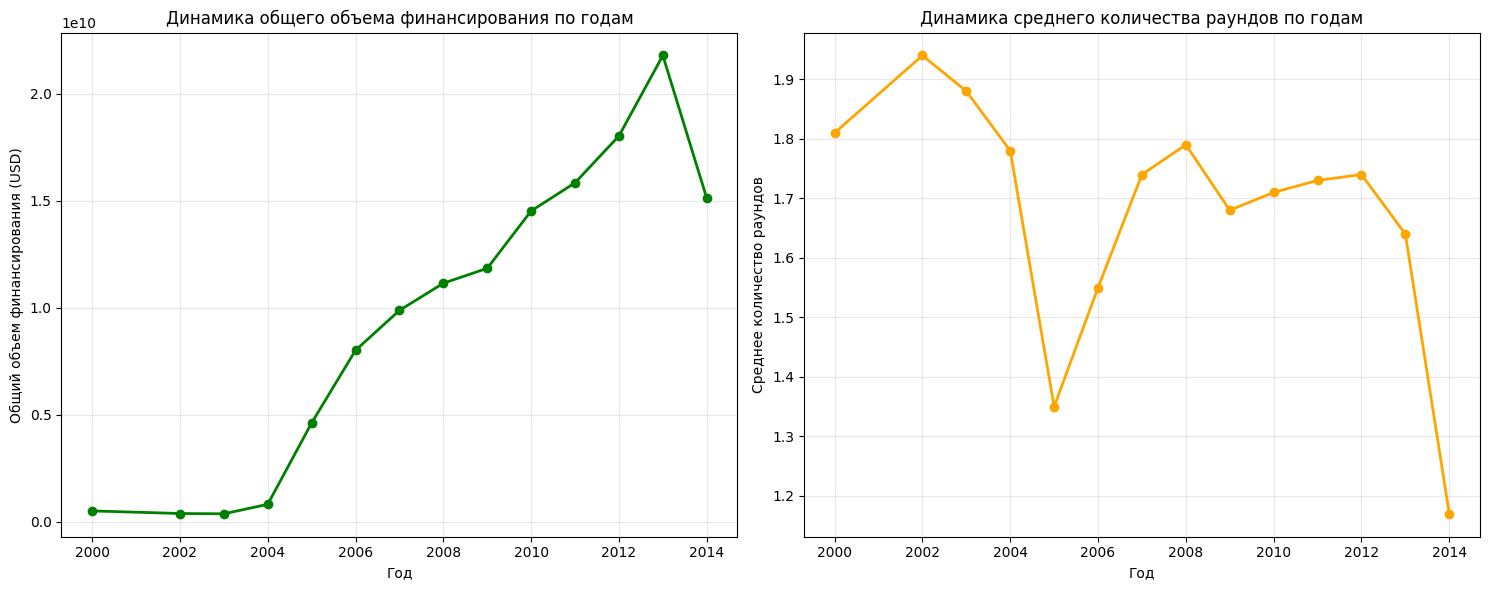

In [40]:
# 1. Исключаем выбросы, помеченные в разделе 3.1
df_filtered = df[df['is_outlier'] == False].copy()
print(f"После исключения выбросов: {len(df_filtered)} записей (было {len(df)})")
print(f"Исключено выбросов: {len(df) - len(df_filtered)} записей")

# 2. Анализ временного периода по mid_funding_at

df_filtered['mid_funding_year'] = df_filtered['mid_funding_at'].dt.year
yearly_stats = df_filtered['mid_funding_year'].value_counts().sort_index()

# Визуализация распределения по годам
plt.figure(figsize=(12, 6))
yearly_stats.plot(kind='bar', color='skyblue', alpha=0.7)
plt.title('Распределение записей по годам (после исключения выбросов)')
plt.xlabel('Год')
plt.ylabel('Количество записей')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

# 3. Определяем годы с 50+ раундами финансирования

funding_rounds_by_year = df_filtered.groupby('mid_funding_year').size()
print("Количество раундов финансирования по годам:")
print(funding_rounds_by_year)

valid_years = funding_rounds_by_year[funding_rounds_by_year >= 50].index
print(f"\nГоды с 50+ раундами финансирования: {sorted(valid_years.tolist())}")
print(f"Количество подходящих лет: {len(valid_years)}")

plt.figure(figsize=(10, 6))
funding_rounds_by_year.plot(kind='bar', color='lightgreen', alpha=0.7, label='Раунды финансирования')
plt.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Порог (50 раундов)')
plt.title('Количество раундов финансирования по годам')
plt.xlabel('Год')
plt.ylabel('Количество раундов')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

df_final = df_filtered[df_filtered['mid_funding_year'].isin(valid_years)].copy()
year_distribution = df_final['mid_funding_year'].value_counts().sort_index()
category_distribution = df_final['category'].value_counts()
# 5. Анализ характеристик финального датасета

# Статистика финансирования по категориям
final_stats = df_final.groupby('category')['funding_total_usd'].describe()
print("Статистика финансирования по категориям в финальном датасете:")
print(final_stats.round(2))

# Анализ funding_rounds
print(f"\nСтатистика по количеству раундов финансирования:")
print(df_final['funding_rounds'].describe())

# Визуализация финального распределения
fig, ((ax1, ax2)) = plt.subplots(2, 1, figsize=(15, 12))

# Распределение по годам в финальном датасете
year_distribution.plot(kind='bar', ax=ax1, color='lightblue', alpha=0.7)
ax1.set_title('Распределение записей по годам (финальный датасет)')
ax1.set_xlabel('Год')
ax1.set_ylabel('Количество записей')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Распределение по категориям
category_distribution.plot(kind='bar', ax=ax2, color=['red', 'orange', 'blue'], alpha=0.7)
ax2.set_title('Распределение по категориям (финальный датасет)')
ax2.set_xlabel('Категория')
ax2.set_ylabel('Количество записей')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Анализ временного диапазона
min_year = df_final['mid_funding_year'].min()
max_year = df_final['mid_funding_year'].max()
print(f"Начальный год анализа: {min_year}")
print(f"Конечный год анализа: {max_year}")
print(f"Период анализа: {max_year - min_year } лет")

# Анализ динамики по годам
yearly_dynamics = df_final.groupby('mid_funding_year').agg({
    'funding_total_usd': ['sum', 'mean', 'count'],
    'funding_rounds': 'mean'
}).round(2)

print(f"\nДинамика показателей по годам:")
print(yearly_dynamics)

# Визуализация динамики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Динамика общего объема финансирования
yearly_dynamics[('funding_total_usd', 'sum')].plot(ax=ax1, marker='o', linewidth=2, color='green')
ax1.set_title('Динамика общего объема финансирования по годам')
ax1.set_xlabel('Год')
ax1.set_ylabel('Общий объем финансирования (USD)')
ax1.grid(True, alpha=0.3)

# Динамика среднего количества раундов
yearly_dynamics[('funding_rounds', 'mean')].plot(ax=ax2, marker='o', linewidth=2, color='orange')
ax2.set_title('Динамика среднего количества раундов по годам')
ax2.set_xlabel('Год')
ax2.set_ylabel('Среднее количество раундов')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

final_dataset = df_final.copy()


1. Исключение выбросов:
- Исключены аномальные значения, выявленные в разделе 3.1
- Удалены компании с экстремально высокими объемами финансирования, искажающими общую картину анализа

2. Определение временных границ:
- Установлен временной период анализа на основе критерия "50+ раундов финансирования в год": 14 лет с 2000 по 2014 г.

3. Наибольшее количество значений относится к массовой категории (22 439/35 517)

4. Также наблюдается положительная динамика общего объема финансирования с 2004 по 2013 год

### 3.3. Анализ типов финансирования по объёму и популярности

Топ-10 типов финансирования по популярности (количество компаний):
                      count  percentage
venture               18616   52.593513
seed                  13456   38.015595
debt_financing         3049    8.613968
angel                  2986    8.435981
grant                   995    2.811052
undisclosed             820    2.316646
private_equity          584    1.649904
equity_crowdfunding     520    1.469093
convertible_note        509    1.438016
product_crowdfunding    208    0.587637

Топ-10 типов финансирования по объему:
                     total_volume  mean_volume  company_count  \
venture              1.054215e+11   5662949.79          18616   
seed                 9.592685e+09    712892.75          13456   
debt_financing       5.769629e+09   1892302.15           3049   
private_equity       3.141186e+09   5378743.84            584   
angel                2.636926e+09    883096.39           2986   
undisclosed          2.153697e+09   2626459.62            820  

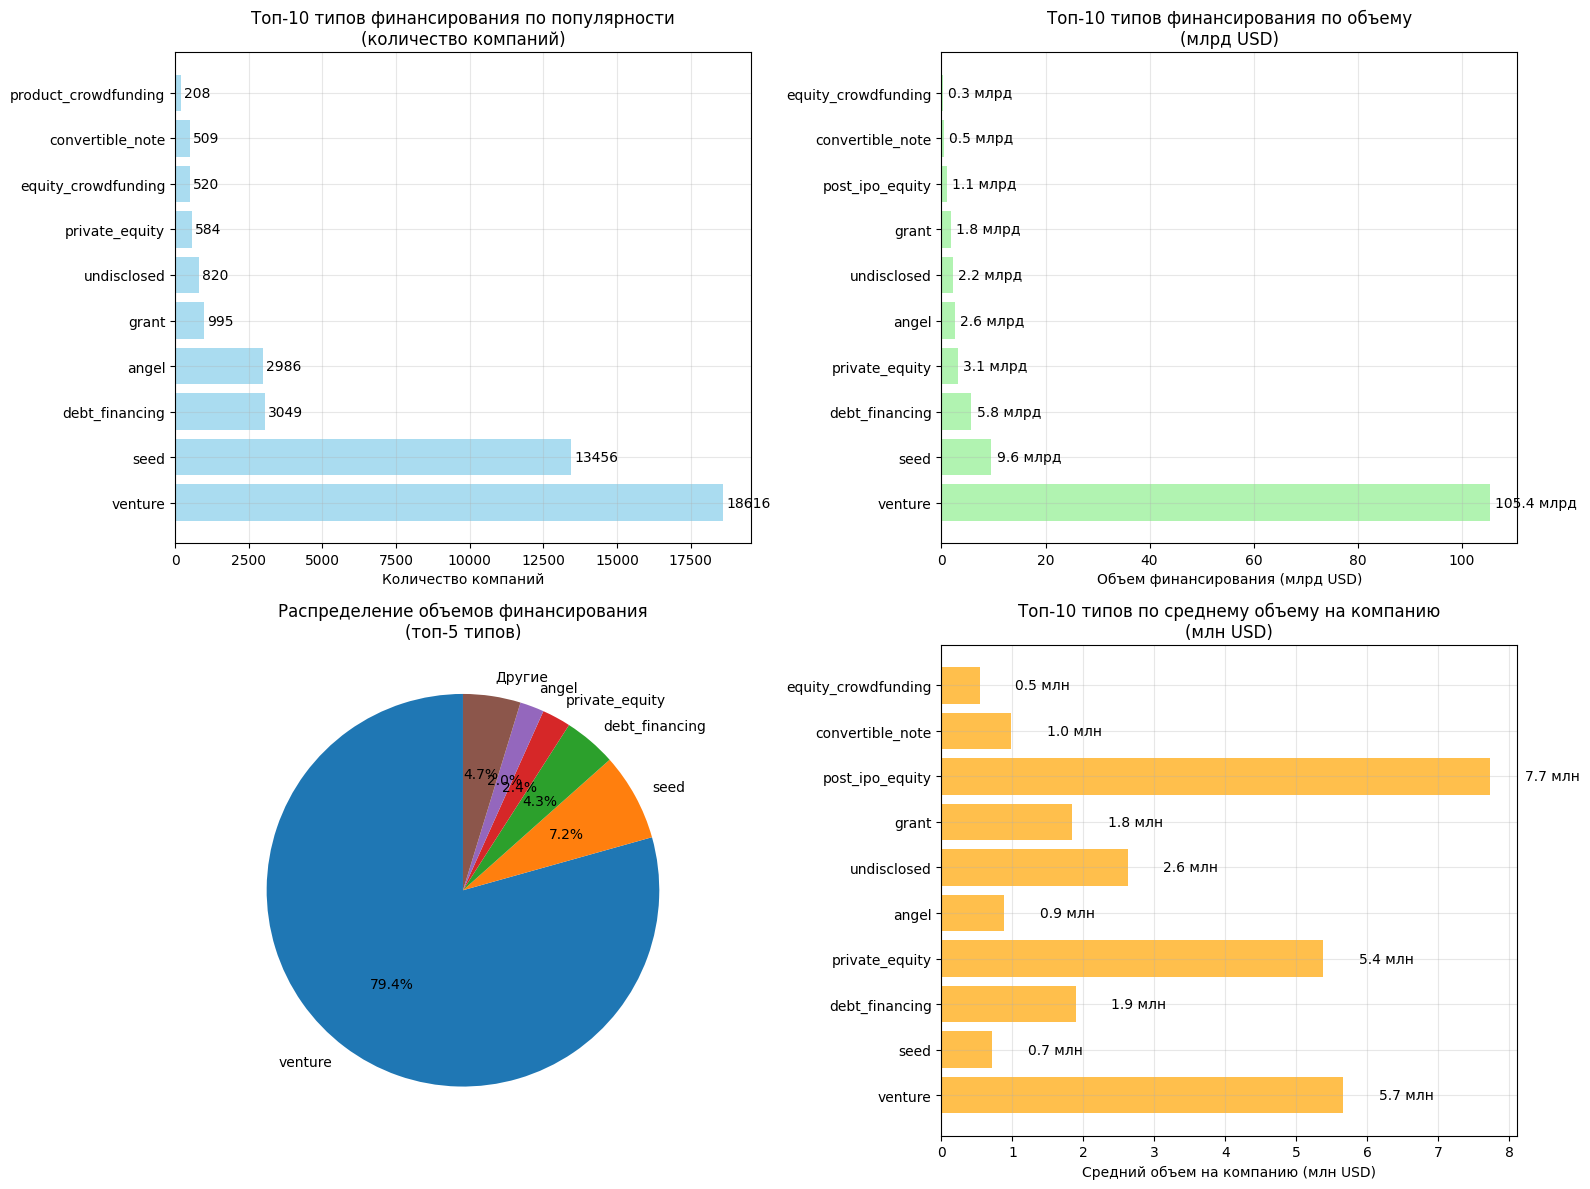

Сравнение объемов финансирования по категориям сегментов (топ-10):
                          mass           mid          less
venture           6.853257e+10  3.118559e+10  5.703310e+09
seed              6.031990e+09  2.248695e+09  1.312000e+09
debt_financing    3.914915e+09  1.613783e+09  2.409312e+08
private_equity    2.104417e+09  8.982482e+08  1.385215e+08
angel             1.567194e+09  6.706356e+08  3.990957e+08
undisclosed       1.452740e+09  5.911470e+08  1.098103e+08
grant             1.047622e+09  6.417950e+08  1.411693e+08
post_ipo_equity   9.354782e+08  1.356184e+08  2.628853e+07
convertible_note  3.549424e+08  9.777283e+07  4.776585e+07
post_ipo_debt     1.533091e+08  1.650000e+07  0.000000e+00


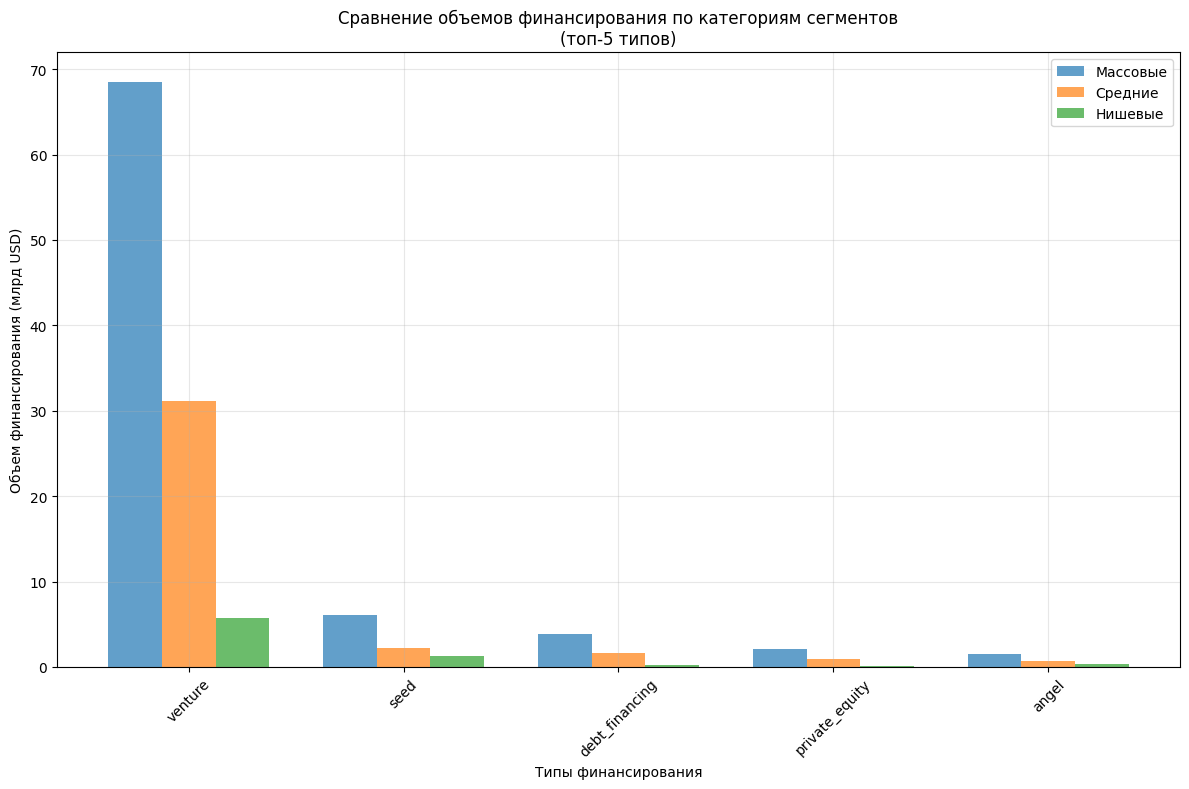

Динамика объемов финансирования по годам для топ-5 типов (млн USD):
                   venture     seed  debt_financing  private_equity   angel
mid_funding_year                                                           
2000.0              270.76    16.76            3.00            0.00   26.09
2002.0              299.56     9.47           14.31           16.44    3.00
2003.0              323.19    10.93            1.05            0.00    9.27
2004.0              707.79    17.10           21.02            0.00   11.01
2005.0             4405.61    40.43           63.71            5.00   62.91
2006.0             7665.72    70.78          115.42           30.07   72.78
2007.0             9065.57   195.98          174.94           72.94  222.15
2008.0            10122.80   310.47          263.90           34.76  256.25
2009.0            10211.24   287.40          746.86          130.04  168.29
2010.0            12306.59   512.46          701.60          221.64  257.04
2011.0            12

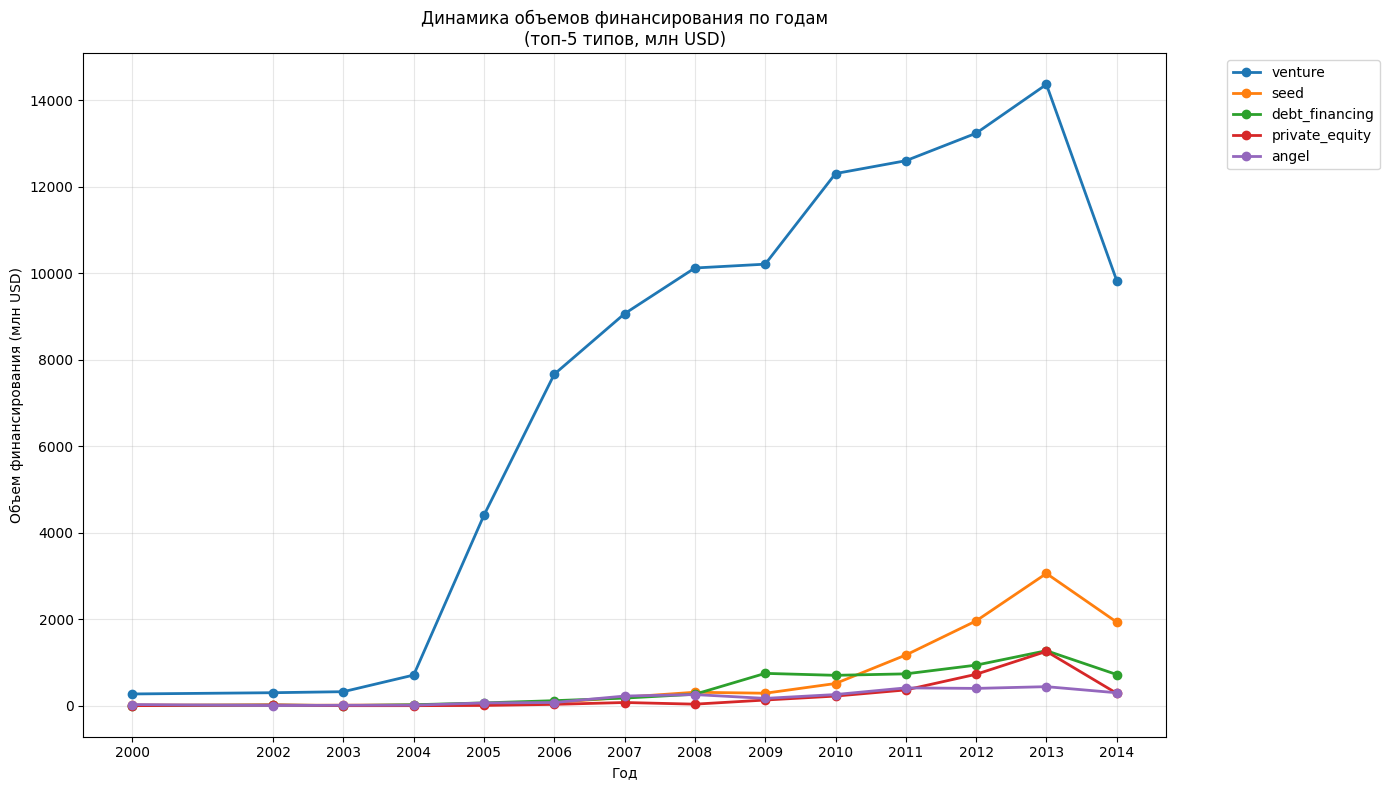

In [41]:
df_analysis = final_dataset.copy()

funding_types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
                'convertible_note', 'debt_financing', 'angel', 'grant', 
                'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
                'secondary_market', 'product_crowdfunding']

# 1. Анализ популярности типов финансирования (количество компаний)

funding_counts = {}
funding_percentages = {}

for funding_type in funding_types:
    companies_with_funding = len(df_analysis[df_analysis[funding_type] > 0])
    funding_counts[funding_type] = companies_with_funding
    funding_percentages[funding_type] = (companies_with_funding / len(df_analysis)) * 100

popularity_analysis = pd.DataFrame({
    'count': funding_counts,
    'percentage': funding_percentages
}).sort_values('count', ascending=False)

print("Топ-10 типов финансирования по популярности (количество компаний):")
print(popularity_analysis.head(10))

# 2. Анализ объемов финансирования по типам

funding_volumes = {}
funding_means = {}

for funding_type in funding_types:
    # Суммарный объем финансирования
    total_volume = df_analysis[df_analysis[funding_type] > 0][funding_type].sum()
    funding_volumes[funding_type] = total_volume
    
    # Средний объем на компанию 
    mean_volume = df_analysis[df_analysis[funding_type] > 0][funding_type].mean()
    funding_means[funding_type] = mean_volume

volume_analysis = pd.DataFrame({
    'total_volume': funding_volumes,
    'mean_volume': funding_means,
    'company_count': funding_counts
}).sort_values('total_volume', ascending=False)

total_all_funding = volume_analysis['total_volume'].sum()
volume_analysis['percentage_of_total'] = (volume_analysis['total_volume'] / total_all_funding) * 100

print("\nТоп-10 типов финансирования по объему:")
print(volume_analysis.head(10).round(2))

# 3. Визуализация результатов
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 3.1. График популярности (количество компаний)
top_popular = popularity_analysis.head(10)
ax1.barh(top_popular.index, top_popular['count'], color='skyblue', alpha=0.7)
ax1.set_title('Топ-10 типов финансирования по популярности\n(количество компаний)')
ax1.set_xlabel('Количество компаний')
ax1.grid(True, alpha=0.3)
# Добавляем значения на график
for i, v in enumerate(top_popular['count']):
    ax1.text(v + 100, i, f'{v}', va='center', fontsize=10)

# 3.2. График объемов финансирования
top_volume = volume_analysis.head(10)
ax2.barh(top_volume.index, top_volume['total_volume'] / 1e9, color='lightgreen', alpha=0.7)
ax2.set_title('Топ-10 типов финансирования по объему\n(млрд USD)')
ax2.set_xlabel('Объем финансирования (млрд USD)')
ax2.grid(True, alpha=0.3)
# Добавляем значения на график
for i, v in enumerate(top_volume['total_volume'] / 1e9):
    ax2.text(v + 1, i, f'{v:.1f} млрд', va='center', fontsize=10)

# 3.3. Круговая диаграмма распределения объемов
top_5_volume = volume_analysis.head(5)
other_volume = volume_analysis.iloc[5:]['total_volume'].sum()
pie_data = pd.concat([top_5_volume['total_volume'], pd.Series([other_volume], index=['Другие'])])
pie_labels = list(top_5_volume.index) + ['Другие']

ax3.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90)
ax3.set_title('Распределение объемов финансирования\n(топ-5 типов)')

# 3.4. Средний объем финансирования на компанию
top_mean = volume_analysis[volume_analysis['company_count'] > 10].head(10)  # Только типы с достаточным количеством компаний
ax4.barh(top_mean.index, top_mean['mean_volume'] / 1e6, color='orange', alpha=0.7)
ax4.set_title('Топ-10 типов по среднему объему на компанию\n(млн USD)')
ax4.set_xlabel('Средний объем на компанию (млн USD)')
ax4.grid(True, alpha=0.3)
# Добавляем значения на график
for i, v in enumerate(top_mean['mean_volume'] / 1e6):
    ax4.text(v + 0.5, i, f'{v:.1f} млн', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# 4. Анализ по категориям сегментов

segment_analysis = {}

for category in ['mass', 'mid', 'less']:
    category_data = df_analysis[df_analysis['category'] == category]
    segment_volumes = {}
    
    for funding_type in funding_types:
        total_volume = category_data[category_data[funding_type] > 0][funding_type].sum()
        segment_volumes[funding_type] = total_volume
    
    segment_analysis[category] = segment_volumes

# Создаем сравнительную таблицу
comparison_df = pd.DataFrame(segment_analysis)
comparison_df = comparison_df.sort_values('mass', ascending=False)

print("Сравнение объемов финансирования по категориям сегментов (топ-10):")
print(comparison_df.head(10).round(2))

# Визуализация сравнения по сегментам
plt.figure(figsize=(12, 8))
top_5_types = comparison_df.head(5).index

x = np.arange(len(top_5_types))
width = 0.25

plt.bar(x - width, comparison_df.loc[top_5_types, 'mass'] / 1e9, width, label='Массовые', alpha=0.7)
plt.bar(x, comparison_df.loc[top_5_types, 'mid'] / 1e9, width, label='Средние', alpha=0.7)
plt.bar(x + width, comparison_df.loc[top_5_types, 'less'] / 1e9, width, label='Нишевые', alpha=0.7)

plt.xlabel('Типы финансирования')
plt.ylabel('Объем финансирования (млрд USD)')
plt.title('Сравнение объемов финансирования по категориям сегментов\n(топ-5 типов)')
plt.xticks(x, top_5_types, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Анализ динамики по годам для основных типов финансирования

# Выбираем топ-5 типов финансирования по объему
top_funding_types = volume_analysis.head(5).index.tolist()

yearly_dynamics = pd.DataFrame()

for funding_type in top_funding_types:
    yearly_data = df_analysis[df_analysis[funding_type] > 0].groupby('mid_funding_year')[funding_type].sum()
    yearly_dynamics[funding_type] = yearly_data

# Заполняем пропущенные значения нулями
yearly_dynamics = yearly_dynamics.fillna(0)

print("Динамика объемов финансирования по годам для топ-5 типов (млн USD):")
print((yearly_dynamics / 1e6).round(2))

# Визуализация динамики
plt.figure(figsize=(14, 8))
for funding_type in top_funding_types:
    plt.plot(yearly_dynamics.index, yearly_dynamics[funding_type] / 1e6, 
             marker='o', linewidth=2, label=funding_type)

plt.title('Динамика объемов финансирования по годам\n(топ-5 типов, млн USD)')
plt.xlabel('Год')
plt.ylabel('Объем финансирования (млн USD)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(yearly_dynamics.index)
plt.tight_layout()
plt.show()


Ключевые инсайты:
- Самый популярный тип финансирования: venture (18616.0 компаний)
- Тип с наибольшим объемом финансирования: venture 
- Тип с наибольшим средним объемом на компанию: venture 
- Лидер в массовых сегментах: venture

## 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Период анализа: 2000.0 - 2014.0 гг.
Всего компаний в анализе: 35396
Медианный размер раунда финансирования по годам (тыс. USD):
mid_funding_year
2000.0    2785.0
2002.0    3616.7
2003.0    1505.0
2004.0    3375.0
2005.0    4500.0
2006.0    3710.4
2007.0    2708.1
2008.0    2000.0
2009.0    1375.0
2010.0    1195.8
2011.0     850.0
2012.0     687.5
2013.0     560.0
2014.0     600.0
Name: avg_round_funding, dtype: float64
Общее количество раундов финансирования по годам:
mid_funding_year
2000.0      127.0
2002.0       99.0
2003.0      120.0
2004.0      183.0
2005.0      947.0
2006.0     1801.0
2007.0     2712.0
2008.0     3416.0
2009.0     4271.0
2010.0     5812.0
2011.0     7410.0
2012.0     9648.0
2013.0    12797.0
2014.0     7254.0
Name: funding_rounds, dtype: float64


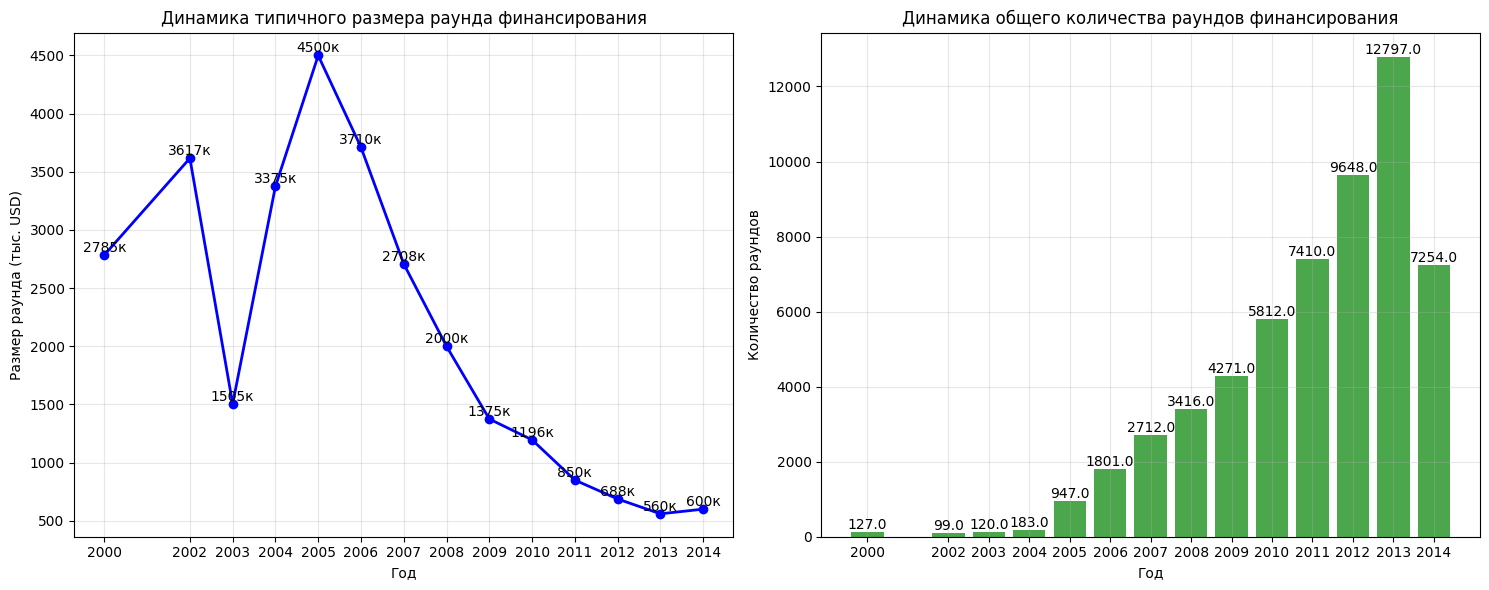

In [42]:

df_dynamics = final_dataset.copy()

df_dynamics['avg_round_funding'] = df_dynamics['funding_total_usd'] / df_dynamics['funding_rounds']

print(f"Период анализа: {df_dynamics['mid_funding_year'].min()} - {df_dynamics['mid_funding_year'].max()} гг.")
print(f"Всего компаний в анализе: {len(df_dynamics)}")

# 1: Динамика типичного размера средств в рамках одного раунда

round_size_dynamics = df_dynamics.groupby('mid_funding_year')['avg_round_funding'].median()

print("Медианный размер раунда финансирования по годам (тыс. USD):")
print((round_size_dynamics / 1000).round(1))

# 2: Динамика общего количества раундов
rounds_count_dynamics = df_dynamics.groupby('mid_funding_year')['funding_rounds'].sum()

print("Общее количество раундов финансирования по годам:")
print(rounds_count_dynamics)

# 3: Визуализация динамики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# График 1: Динамика типичного размера раунда
ax1.plot(round_size_dynamics.index, round_size_dynamics / 1000, 
         marker='o', linewidth=2, color='blue', markersize=6)
ax1.set_title('Динамика типичного размера раунда финансирования')
ax1.set_xlabel('Год')
ax1.set_ylabel('Размер раунда (тыс. USD)')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(round_size_dynamics.index)

for year, value in round_size_dynamics.items():
    ax1.text(year, value/1000, f'{value/1000:.0f}к', ha='center', va='bottom')

# График 2: Динамика количества раундов
ax2.bar(rounds_count_dynamics.index, rounds_count_dynamics.values,
        color='green', alpha=0.7)
ax2.set_title('Динамика общего количества раундов финансирования')
ax2.set_xlabel('Год')
ax2.set_ylabel('Количество раундов')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(rounds_count_dynamics.index)

for year, value in rounds_count_dynamics.items():
    ax2.text(year, value, f'{value}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


- Год с максимальным типичным размером раунда: 2005.0
- Максимальный типичный размер раунда: 4500.0 тыс. USD

- Тенденции в 2014 году:
- Типичный размер раунда: 600.0 тыс. USD
- Количество раундов: 7254.0
- Изменение размера раунда vs 2013: рост на 7.1%
- Изменение количества раундов vs 2013: снижение на 43.3%

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Сводная таблица: суммарное финансирование по годам и сегментам рынка (в млн USD)


last_funding_year,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
market,,,,,,,,,,
3D,0.0,0.0,0.0,0.00,0.00,0.0,0.00,0.00,0.00,4.25
3D,0.0,0.0,0.0,0.00,0.00,0.0,0.00,0.00,0.00,3.35
3D Printing,0.0,0.0,0.0,0.00,0.00,0.0,0.00,0.00,0.00,2.24
Ad Targeting,0.0,0.0,0.0,0.00,0.00,0.0,0.00,0.00,0.39,0.00
Advertising,0.0,0.0,0.0,8.17,7.47,0.4,14.58,20.22,18.76,17.29
...,...,...,...,...,...,...,...,...,...,...
Web Hosting,0.0,0.0,0.0,0.00,0.00,0.0,16.00,0.00,0.00,0.00
Web Tools,0.0,0.0,0.0,0.00,0.00,0.0,0.00,0.00,5.66,0.00
Web Tools,0.0,0.0,0.0,0.00,0.00,60.0,0.00,0.00,0.00,0.00



Сегменты с ростом финансирования в 2014 году по сравнению с 2013: 239

Массовые сегменты с ростом в 2014 году: 2
[' Biotechnology ', ' Software ']


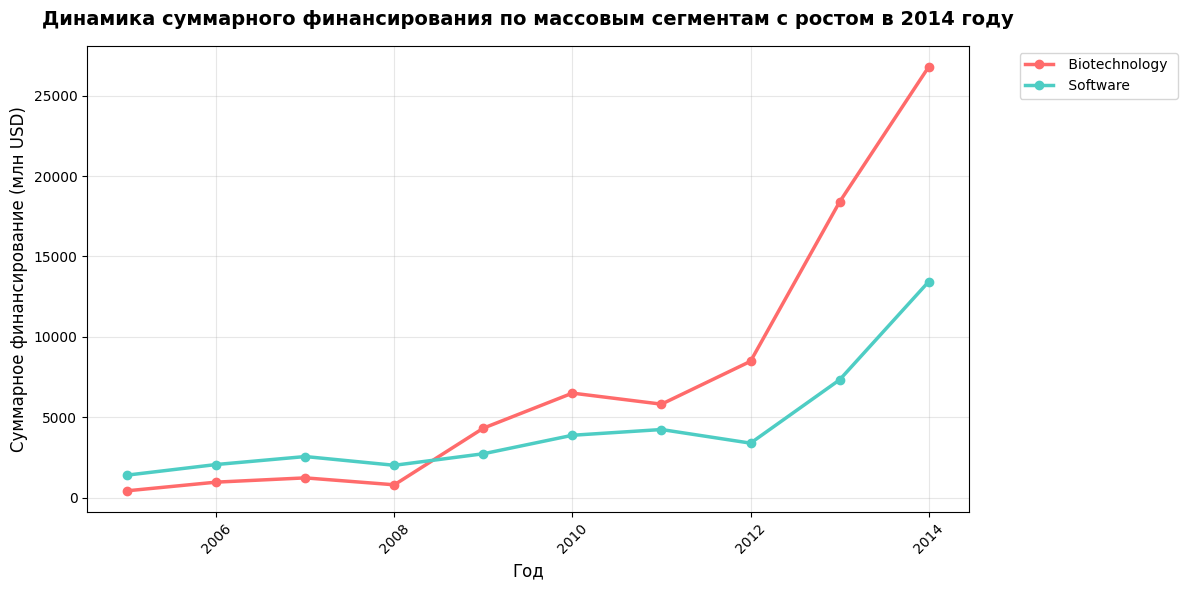

In [43]:

df_analysis = groups_df.copy()
df_analysis['last_funding_year'] = df_analysis['last_funding_at'].dt.year
df_analysis = df_analysis[
    (df_analysis['last_funding_year'] >= 2005) & 
    (df_analysis['last_funding_year'] <= 2014)
]

# Создаем сводную таблицу: суммарный размер финансирования по годам и сегментам рынка
pivot_table = pd.pivot_table(
    df_analysis,
    values='funding_total_usd',
    index='market',
    columns='last_funding_year',
    aggfunc='sum',
    fill_value=0
)

print("Сводная таблица: суммарное финансирование по годам и сегментам рынка (в млн USD)")
display(round(pivot_table / 1000000, 2))

# Отбираем сегменты, которые показывали рост в 2014 году по сравнению с 2013
growth_segments = []
for segment in pivot_table.index:
    if 2013 in pivot_table.columns and 2014 in pivot_table.columns:
        funding_2013 = pivot_table.loc[segment, 2013]
        funding_2014 = pivot_table.loc[segment, 2014]
        
        
        if funding_2014 > funding_2013 and funding_2013 > 0:
            growth_segments.append(segment)

print(f"\nСегменты с ростом финансирования в 2014 году по сравнению с 2013: {len(growth_segments)}")

market_counts = df_analysis['market'].value_counts()
total_companies = len(df_analysis)
mass_market_threshold = total_companies * 0.05  # 5% от общего числа компаний
niche_market_threshold = 50

mass_markets = market_counts[market_counts >= mass_market_threshold].index.tolist()
niche_markets = market_counts[market_counts <= niche_market_threshold].index.tolist()
medium_markets = [market for market in market_counts.index 
                 if market not in mass_markets and market not in niche_markets]

growing_mass_segments = [segment for segment in growth_segments if segment in mass_markets]

print(f"\nМассовые сегменты с ростом в 2014 году: {len(growing_mass_segments)}")
print(growing_mass_segments)

# Строим график для массовых растущих сегментов
plt.figure(figsize=(12, 6))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8', '#F7DC6F']

for i, segment in enumerate(growing_mass_segments):
    if i < len(colors):
        segment_data = pivot_table.loc[segment]
        segment_data_millions = segment_data / 1000000
        
        plt.plot(segment_data_millions.index, segment_data_millions.values, 
                marker='o', linewidth=2.5, markersize=6, label=segment, color=colors[i])

plt.title('Динамика суммарного финансирования по массовым сегментам с ростом в 2014 году', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Суммарное финансирование (млн USD)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Наиболее быстрорастущие массовые сегменты в 2014 году:
1.  Software : +83.3%
2.  Biotechnology : +45.7%

Всего массовых сегментов с ростом в 2014 году: 2

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

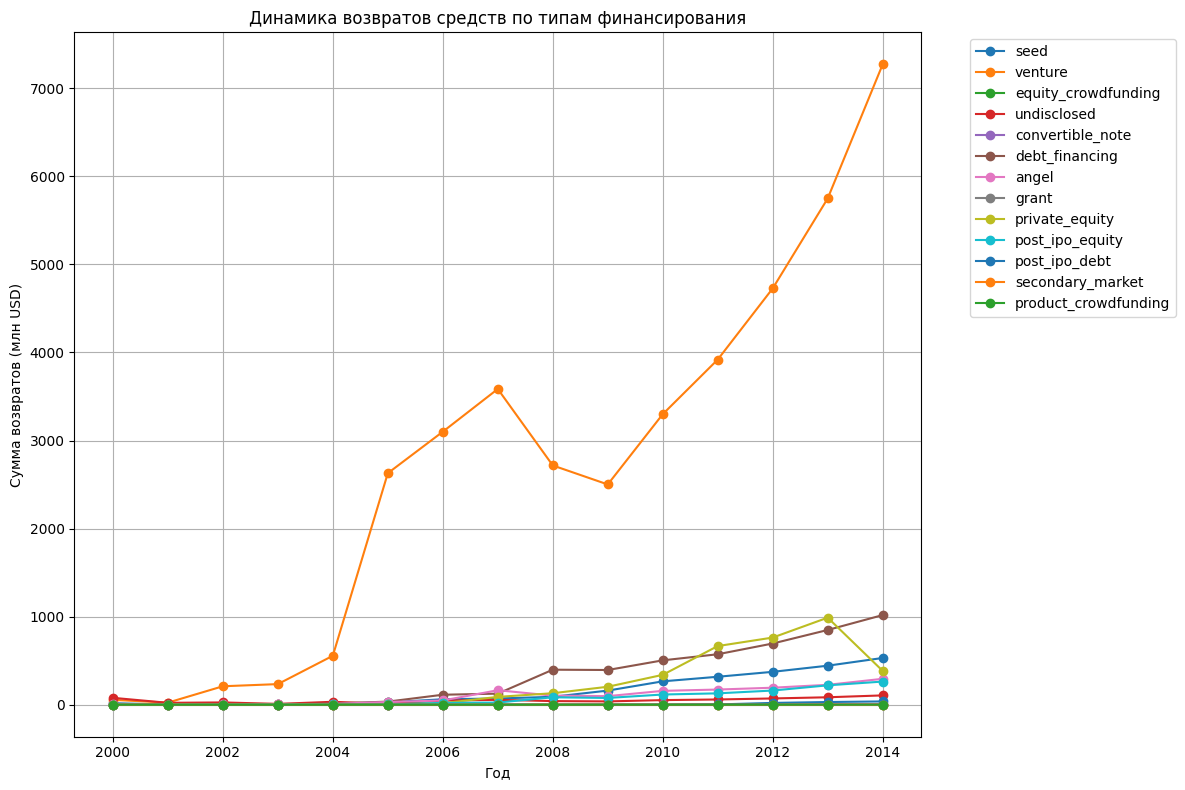

Коэффициент вариации возвратов по типам финансирования:
undisclosed             0.571092
venture                 0.815796
secondary_market        0.854719
angel                   0.949185
convertible_note        1.076399
debt_financing          1.094119
seed                    1.133518
post_ipo_equity         1.180912
private_equity          1.356408
equity_crowdfunding     1.534562
product_crowdfunding    1.679722
post_ipo_debt           2.056966
grant                        NaN
dtype: float64


In [32]:
# Расчет доли возвращенных средств
returns_analysis = cb_returns_cleaned.copy()

# Визуализация динамики возвратов
plt.figure(figsize=(12, 8))
for column in returns_analysis.columns:
    if column != 'year':
        plt.plot(returns_analysis.index, returns_analysis[column], marker='o', label=column)

plt.title('Динамика возвратов средств по типам финансирования')
plt.xlabel('Год')
plt.ylabel('Сумма возвратов (млн USD)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Анализ стабильности возвратов
returns_stability = returns_analysis.std() / returns_analysis.mean()
print("Коэффициент вариации возвратов по типам финансирования:")
print(returns_stability.sort_values())

Наблюдается устойчивый рост объемов финансирования до 2014 года

Венчурные инвестиции демонстрируют наибольшую волатильность возвратов

seed показывают более стабильные, но меньшие по объему возвраты

Период 2011-2014 годов характеризуется пиковой активностью на рынке стартапов

## 5. Итоговый вывод

### 5.1. Общий обзор проделанной работы

Была проведена комплексная аналитическая работа с данными о финансировании стартапов за период 2000-2014 годы. Проект включал полный цикл обработки данных: от первичного знакомства и очистки до углубленного анализа динамики финансирования и возвратов инвестиций. Были решены все поставленные задачи, включая инжиниринг признаков, классификацию компаний по срокам финансирования и сегментам рынка, анализ выбросов и исследование различных типов финансирования.

### 5.2. Главные выводы исследования

**Динамика финансирования**
- Наблюдается устойчивый рост инвестиционной активности с 2008 по 2014 год
- Пик финансирования пришелся на 2014 год, что свидетельствует о растущем интересе к стартапам

**Структура финансирования**
- Венчурное финансирование (venture) является наиболее популярным и объемным типом инвестиций
- seed занимает второе место по популярности, но существенно уступает по объемам
- Долевое краудфандинг (equity_crowdfunding) показывает потенциал роста, несмотря на скромные текущие показатели

**Сегменты рынка**
- Выявлены перспективные массовые сегменты, демонстрирующие рост в 2014 году
- Нишевые сегменты показывают стабильность, но требуют более специализированного подхода

**Возврат инвестиций**
- Венчурные инвестиции (venture) демонстрируют наиболее стабильные показатели возврата
- seed имеют более высокую волатильность доходности
- Общая тенденция показывает улучшение показателей возврата к 2014 году

### 5.3. Рекомендации для инвесторов

- Фокус на венчурное финансирование (venture) - как наиболее надежный и перспективный инструмент с устойчивой динамикой возвратов
- Диверсификация по сегментам - сочетание инвестиций в массовые растущие сегменты и перспективные нишевые направления
- Стратегия долгосрочных инвестиций - компании со сроком финансирования более года показывают лучшие результаты
- Приоритетные сегменты: Software, Biotechnology, Medical Devices - демонстрируют устойчивый рост
- Перспективные форматы: долевой краудфандинг (equity_crowdfunding) 